# ST445 Final Project: Sector Resilience in the FTSE 100 during Crises

### Candidate Numbers: 66498, 61396, 70624

# Notebook Instructions and Prerequisites

To run this notebook, make sure these packages are installed in your environment:

- requests  
- pandas  
- numpy  
- beautifulsoup4  
- yfinance  
- matplotlib  
- scikit-learn  
- ipywidgets  

In [1]:
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from io import StringIO
import re
from datetime import datetime
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from ipywidgets import interactive, IntRangeSlider, SelectionRangeSlider, Checkbox, VBox, HBox, Output
from IPython.display import display

# Table of Contents

- [**Introduction**](#introduction)
  - [Motivation](#motivation)
  - [Research Question](#research-question)
- [**Data Description and Collection**](#data-description-and-collection)
  - [Background to Crises (Brexit & COVID-19)](#background-for-crises-brexit--covid-19)
    - [Brexit Polling Data](#brexit-polling-data)
    - [UK COVID-19 Data](#uk-covid-19-data)
  - [FTSE 100 Stocks & Sectors](#ftse-100-stocks--sectors)
    - [Major Sectors in the FTSE 100 (as of 2025)](#major-sectors-in-the-ftse-100-as-of-2025)
    - [Stock Ticker Labels for Major Sector Companies in the FTSE 100](#stock-ticker-labels-for-major-sector-companies-in-the-ftse-100)
    - [Historical Stock Data from Yahoo Finance](#historical-stock-data-from-yahoo-finance)
- [**Exploratory Analysis and Visualization**](#exploratory-analysis-and-visualization)
  - [Descriptive Statistics](#descriptive-statistics)
  - [Comparison of COVID-19 and Brexit Effects on Different Sectors and Companies](#comparison-of-covid-19-and-brexit-effects-on-different-sectors-and-companies)
    - [Major FTSE 100 Sectors: Returns and Cumulative Returns](#major-ftse-100-sectors-gainloss-over-time---returns-and-cumulative-returns)
    - [Zoomed-in Windows for FTSE 100 Sector Cumulative Returns](#zoomed-in-windows-for-ftse-100-cumulative-returns-on-sector)
    - [Major FTSE 100 Companies: Returns and Cumulative Returns](#major-ftse-100-companies-gainloss-over-time---returns-and-cumulative-returns)
    - [Zoomed-in Windows for FTSE 100 Company Percent Gain/Loss](#zoomed-in-windows-for-ftse-100-company-percent-gainloss)
  - [Which sectors were most volatile in crisis periods?](#which-sectors-were-most-volatile-in-crisis-periods)
  - [Cumulative Return Responses in ±30- and ±60-Day Event Windows](#cumulative-return-responses-in-30--and-60-day-event-windows)
- [**Modeling**](#modeling)
  - [Principal Component Analysis (PCA) on Resilience Metrics (Brexit vs COVID-19)](#principal-component-analysis-pca-on-resilience-metrics-brexit-vs-covid-19)
  - [K-Means Clustering on Resilience Metrics (Brexit vs COVID-19)](#k-means-clustering-on-resilience-metrics-brexit-vs-covid)
  - [Overall Resilience Score by Sector](#overall-resilience-score-by-sector)
- [**Conclusion**](#conclusion)
- [**References**](#references)


# Introduction

### Motivation: 
The FTSE 100 is the UK's flagship equity index, comprising the 100 largest companies listed on the London Stock Exchange (LSE) by market capitalization. Its constituents span a wide range of industries, so the sector-level behavior within the index can differ substantially. Many constituents operate globally, meaning that sector performance within the index reflects both domestic and international economic conditions. As a result, analyzing the FTSE 100 at the sector level offers valuable insight into how different parts of the economy respond to major macroeconomic shocks. In this report, we will find out what the ten major FTSE 100 sectors are, then focus and compare how their return distributions and downside risk profiles change around two major stress events - Brexit and COVID-19.

The Brexit Referendum and the COVID-19 pandemic represent two fundamentally different but highly significant market stress events. The Brexit referendum 2016 introduced a sharp rise in policy uncertainty and was mainly a UK-specific risk. In contrast, COVID-19 triggered a global demand and supply shock that affected economic activity directly. Studying both events allows for a comparison between a policy-driven uncertainty shock (Brexit) and a global demand and activity shock (COVID-19). This helps provide a richer setting to examine how different sectors in the FTSE 100 perform based on the nature of the crisis.

Understanding sector resilience is highly vital, especially for both investors and risk managers. Sector resilience refers to the ability of a sector to withstand market stress and recover following a crisis. Sector-level differences in volatility and recovery speed can significantly influence portfolio performance during periods of market stress. Moreover, sector resilience analysis helps distinguish between sectors that provide defensive characteristics and those that amplify downside risk during extreme events. Thus, identifying which sectors tend to be more resilient can help make a more informed decision on asset allocation and diversification decisions, as well as providing stress-testing frameworks. 

### Research Question:
Motivated by these considerations, this report addresses the following research question:

**How did FTSE 100 major sectors differ in their resilience during the Brexit and COVID-19 crises, and which sectors appeared most resilient across the two events?**

There are four key objectives that we will pursue in this project:
1. To describe the composition of the FTSE 100 at the sector level and identify the most dominant sectors by approximate index weight.
2. To quantify sector-level performance during Brexit and COVID-19 using returns, volatility, drawdowns, and recovery metrics.
3. To compare sector responses across the two crises using visualisation and descriptive statistics.
4. To apply multivariate modelling techniques, including principal component analysis and k-means clustering, to identify patterns of sector resilience, and to construct a rank of resilience.

# Data Description and Collection

Our study involves data sets for Brexit Polling, COVID-19 deaths and cases in the UK, Major TSE 100 Sectors and historical stock data. Specifically the datasets are imported from the sources below:

* **EU Referendum Results** - Greater London Authority (GLA), London Datastore
* **UK COVID-19 API**  - UKHSA Data Dashboard, UK Gov
* **Major Sectors in the FTSE 100 (As of 2025)** - ftse100index.com
* **FTSE 100 Index Wikipedia Page** - Stock Ticker Labels and Company Names
* **Historical Stock Data** - Yahoo Finance Package 

In this section, we will provide some contextual background on the two major crises examined in this report: the Brexit referendum and the COVID-19 pandemic. Together, these two crises offer a natural comparison between a sudden, policy-driven uncertainty shock (Brexit) and a prolonged, global real-economy shock (COVID-19). By establishing their background and timing, this help provide a foundation for analyzing how different FTSE 100 sectors responded and recovered from these two stress events.

We then construct a sector-level representation of the FTSE 100 by identifying the major and most dominant sectors within the index, their approximate index weights, and representative constituent companies. Historical daily stock price data for these companies are obtained from Yahoo Finance and aggregated to the sector level. This allows for consistent measurement of returns, volatility, drawdowns, and recovery behaviour across sectors during both crises.

## Background to Crises (Brexit & COVID-19)


To contextualize, we will first provide some background information on the two crises. Brexit polling and regional voting data are used to characterise the degree of political uncertainty and geographic fragmentation surrounding the 2016 referendum. UK COVID-19 case and death data are then used to identify periods of heightened pandemic severity, helping to motivate the event windows analysed later in the report. These datasets provide an objective basis for defining the timing and nature of the stress events under consideration.

### Brexit Polling Data

To understand the public opinion on Brexit, we first explore how close the vote was in deciding to remain or leave the European Union. Specifically, we look at how each UK region voted in the EU-referendum. A close or regionally divided result could lead to uncertainty, influencing the way the market behave.

In [2]:
#Import EU Referendum Results
brexitCSV = "https://data.london.gov.uk/download/2y548/52dccf67-a2ab-4f43-a6ba-894aaeef169e/EU-referendum-result-data.csv"
brexitInfo = pd.read_csv(brexitCSV, storage_options={"User-Agent": "Mozilla/5.0"})

brexitInfo

,id,Region_Code,Region,Area_Code,Area,Electorate,ExpectedBallots,VerifiedBallotPapers,Pct_Turnout,Votes_Cast,...,Remain,Leave,Rejected_Ballots,No_official_mark,Voting_for_both_answers,Writing_or_mark,Unmarked_or_void,Pct_Remain,Pct_Leave,Pct_Rejected
0,108,E12000006,East,E06000031,Peterborough,120892,87474,87469,72.35,87469,...,34176,53216,77,0,32,7,38,39.11,60.89,0.09
1,109,E12000006,East,E06000032,Luton,127612,84633,84636,66.31,84616,...,36708,47773,135,0,85,0,50,43.45,56.55,0.16
2,112,E12000006,East,E06000033,Southend-on-Sea,128856,93948,93939,72.90,93939,...,39348,54522,69,0,21,0,48,41.92,58.08,0.07
3,113,E12000006,East,E06000034,Thurrock,109897,79969,79954,72.75,79950,...,22151,57765,34,0,8,3,23,27.72,72.28,0.04
4,110,E12000006,East,E06000055,Bedford,119530,86136,86136,72.06,86135,...,41497,44569,69,0,26,1,42,48.22,51.78,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,65,E12000003,Yorkshire and The Humber,E08000032,Bradford,342817,228729,228729,66.72,228727,...,104575,123913,239,0,121,5,113,45.77,54.23,0.10
378,66,E12000003,Yorkshire and The Humber,E08000033,Calderdale,149195,106005,106008,71.05,106004,...,46950,58975,79,0,22,15,42,44.32,55.68,0.07
379,67,E12000003,Yorkshire and The Humber,E08000034,Kirklees,307081,217460,217449,70.80,217428,...,98485,118755,188,0,86,7,95,45.33,54.67,0.09
380,68,E12000003,Yorkshire and The Humber,E08000035,Leeds,543033,387730,387730,71.39,387677,...,194863,192474,340,39,116,8,177,50.31,49.69,0.09


In [3]:
# Define the output widget for displaying plots
output = Output()

# Define the plotting function
def plotBrexit(East, EastMidlands,London,NorthEast, NorthWest,
       NorthernIreland, Scotland, Paisley, SouthWest,
       Wales, WestMidlands, YorkshireTheHumber):
    
    # Collect selected locations
    selected_locations = []
    if East:
        selected_locations.append('East')
    if EastMidlands:
        selected_locations.append('East Midlands')
    if London:
        selected_locations.append('London')
    if NorthEast:
        selected_locations.append('North East')
    if NorthWest:
        selected_locations.append('North West')
    if NorthernIreland:
        selected_locations.append('Northern Ireland')
    if Scotland:
        selected_locations.append('Scotland')
    if Paisley:
        selected_locations.append('Paisley')
    if SouthWest:
        selected_locations.append('South West')
    if Wales:
        selected_locations.append('Wales')
    if WestMidlands:
        selected_locations.append('West Midlands')
    if YorkshireTheHumber:
        selected_locations.append('Yorkshire and The Humber')
        
    # Ensure 1+ locations are selected
    if len(selected_locations) == 0:
        with output:
            output.clear_output()
            print("Please select exactly 1+ regions.")
        return

    # Filter data for the selected year range and locations
    df_filtered = brexitInfo[brexitInfo['Region'].isin(selected_locations)]
    totalVotes = df_filtered[['Remain','Leave']].sum()
    totalUK = brexitInfo[['Remain','Leave']].sum()
    
    # Plot histogram
    with output:
        output.clear_output()
        plt.figure(figsize=(8, 4))

        #Plot selected location pie chart
        plt.subplot(1, 2, 1)
        plt.pie(totalVotes,labels=['Remain','Leave'],
            autopct='%1.1f%%',colors = ['#3776ab','firebrick'],
            pctdistance=0.8,textprops={"color": "white", "fontsize": 14})
        centre_circle = plt.Circle((0,0), 0.60, color='white')
        plt.gca().add_artist(centre_circle)
        plt.title(('Selected Regions'))
       
        #Plot all of UK  pie chart
        plt.subplot(1, 2, 2)
        plt.pie(totalUK,labels=['Remain','Leave'],autopct='%1.1f%%',colors = ['#3776ab','firebrick'],
            pctdistance=0.8, textprops={"color": "white", "fontsize": 14})
        centre_circle = plt.Circle((0,0), 0.60, color='white')
        plt.gca().add_artist(centre_circle)
        plt.title("All UK Regions")
        plt.legend(labels=["Remain", "Leave"],loc="center left",bbox_to_anchor=(1, 0.6))
        plt.tight_layout()
        plt.show()

# Checkbox widgets for location selection
East = Checkbox(value=False, description='East')
EastMidlands = Checkbox(value=False, description='East Midlands')
London = Checkbox(value=True, description='London')
NorthEast= Checkbox(value=False, description='North East')
NorthWest= Checkbox(value=False, description='North West')
NorthernIreland= Checkbox(value=False, description='Northern Ireland')
Scotland= Checkbox(value=False, description='Scotland')
Paisley= Checkbox(value=False, description='Paisley')
SouthWest= Checkbox(value=False, description='South West')
Wales= Checkbox(value=False, description='Wales')
WestMidlands= Checkbox(value=False, description='West Midlands')
YorkshireTheHumber= Checkbox(value=False, description='Yorkshire & The Humber')

# Link the widgets to the plotting function
interactive_hist = interactive(
    plotBrexit, East=East, EastMidlands=EastMidlands,London=London,
    NorthEast=NorthEast, NorthWest=NorthWest,NorthernIreland=NorthernIreland, 
    Scotland=Scotland, Paisley=Paisley, SouthWest=SouthWest,
    Wales=Wales, WestMidlands=WestMidlands, YorkshireTheHumber=YorkshireTheHumber)

# Display the interactive widget layout with checkboxes and year slider
ui1 = HBox([East, EastMidlands,London])
ui2 = HBox([NorthEast, NorthWest,NorthernIreland])
ui3 = HBox([Scotland, Paisley, SouthWest])
ui4 = HBox([Wales,WestMidlands,YorkshireTheHumber])

ui = VBox([ui1,ui2,ui3, ui4,output])
display(ui)

#starting plot
plotBrexit(East.value, EastMidlands.value, London.value, NorthEast.value, NorthWest.value,
           NorthernIreland.value, Scotland.value, Paisley.value, SouthWest.value,
           Wales.value, WestMidlands.value, YorkshireTheHumber.value)


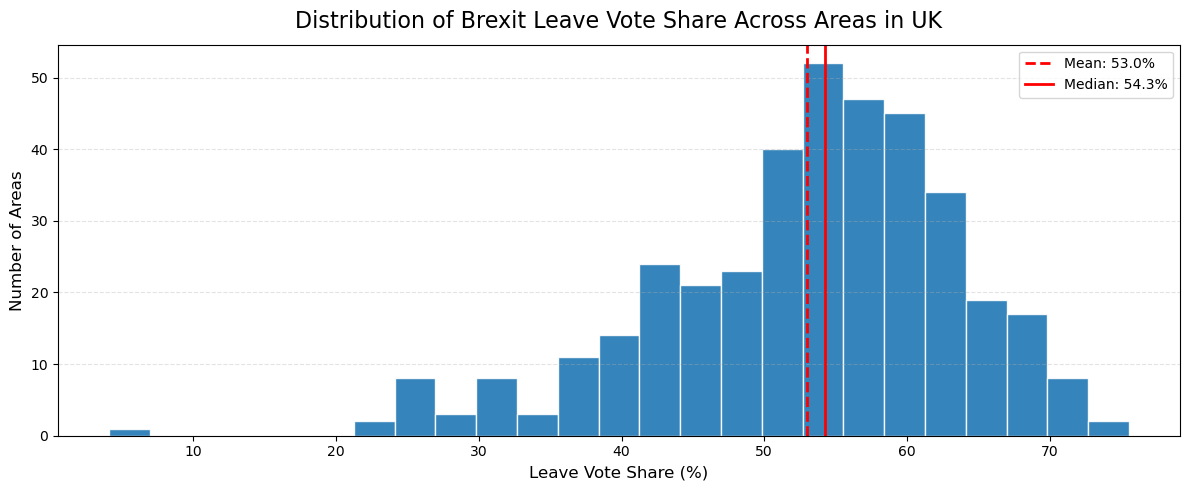

In [4]:
plt.figure(figsize=(12,5))

# Plotting Brexit Leave Vote % Across Areas Counts
plt.hist(
    brexitInfo["Pct_Leave"],
    bins=25,
    edgecolor="white",
    linewidth=1,
    alpha=0.9
)

# Mean & median inclusion for additional insights
mean_val = brexitInfo["Pct_Leave"].mean()
median_val = brexitInfo["Pct_Leave"].median()

# Adding line to mean and median for visual clarity
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.1f}%")
plt.axvline(median_val, color="red", linestyle="-", linewidth=2, label=f"Median: {median_val:.1f}%")

plt.title("Distribution of Brexit Leave Vote Share Across Areas in UK", fontsize=16, pad=12)
plt.xlabel("Leave Vote Share (%)", fontsize=12)
plt.ylabel("Number of Areas", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Average percentage of votes to leave by region
region_leave_avg = (
    brexitInfo.groupby("Region")["Pct_Leave"]
    .mean()
    .sort_values(ascending=False)
)

#Display as data table
region_leave_avg2 = (
   region_leave_avg
    .to_frame(name = "Avg % Votes to Leave")
    .reset_index()
)
region_leave_avg2.style.hide(axis='index')

Region,Avg % Votes to Leave
West Midlands,60.314667
East Midlands,59.574500
North East,59.479167
Yorkshire and The Humber,58.650000
East,56.962128
North West,55.915128
Wales,53.347727
South West,52.379211
South East,52.170000
Northern Ireland,44.220000


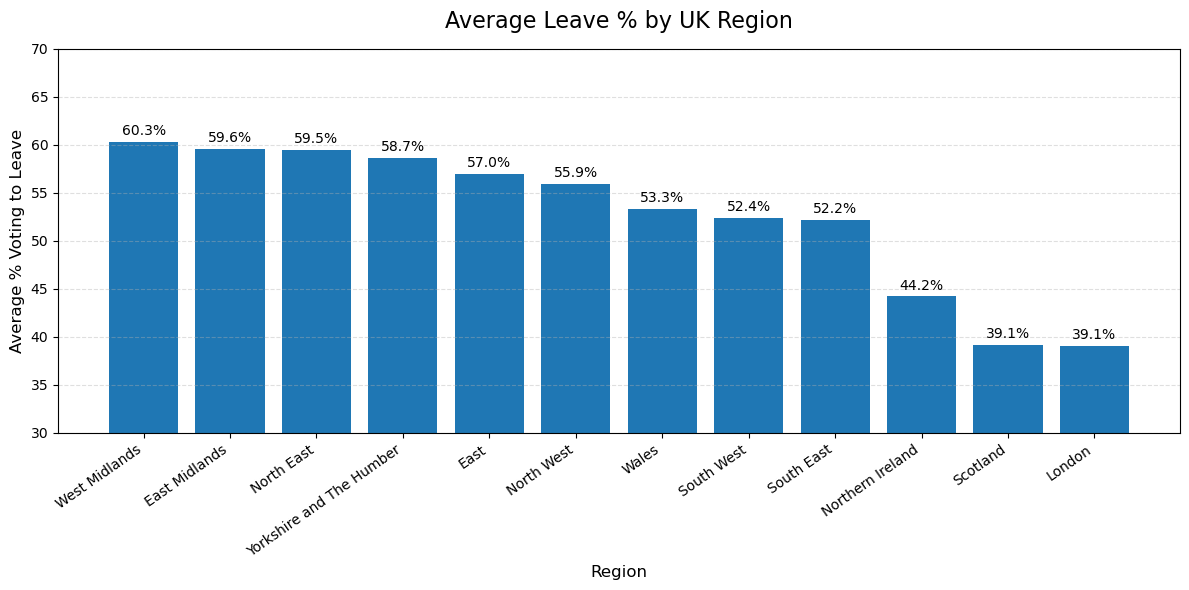

In [6]:
plt.figure(figsize=(12,6))
bars = plt.bar(region_leave_avg.index, region_leave_avg.values)

plt.title("Average Leave % by UK Region", fontsize=16, pad=15)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Average % Voting to Leave", fontsize=12)

plt.ylim(30, 70) # y-axis range
plt.xticks(rotation=35, ha="right")

# adding value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.4,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Findings of Distribution and Regional Patterns**

Together, the distribution of Leave vote shares across local areas and the regional averages indicate that support for Brexit was broad but geographically varied. The distribution shows that the typical local authority voted Leave, with both the mean and median exceeding 50 percent. Variation across areas is substantial, with a small number of strongly Remain-leaning areas generating a left tail in the histogram distribution.

The regional averages help contextualize this pattern, showing that most UK regions recorded average Leave support above a simple majority, while London, Scotland, and Northern Ireland stand out as clear Remain-oriented outliers. Taken together, these figures suggest that the closeness of the national result doesn't fully capture the regional variation. Rather than a uniformly or evenly divided electorate, Brexit support appears to differ on the regional scale quite notably. 

Importantly, this uneven political geography implies that Brexit should not be viewed as a uniform shock to the UK economy. Regions differ in industrial composition, trade exposure, and financial integration, suggesting that the referendum outcome likely translated into asymmetric impacts across sectors and firms. This motivates the subsequent analysis, which examines whether financial markets reflected this heterogeneity through differential sectoral and company-level responses following the Brexit vote.

### UK COVID-19 Data

The second event we are interested in to assess sector resilience is the COVID-19 pandemic. To identify the most severe periods of the pandemic, we plot the daily deaths and cases over time. 

In [7]:
#Import COVID data from ukhsa dashboard API - COVID-19 Cases By Day
url = "https://api.ukhsa-dashboard.data.gov.uk/themes/infectious_disease/sub_themes/respiratory/topics/COVID-19/geography_types/Nation/geographies/England/metrics/COVID-19_cases_casesByDay"

covidData = []
params = {"format": "json", "page_size": 365}

#Loop through API data from COVID-19 Cases By Day
while url:
    req = requests.get(url, params=params)
    x = req.json()
    covidData += x["results"]
    url = x["next"]
    params = None

#Data frame of COVID day data for cases
covidCases = pd.DataFrame(covidData)
covidCases["date"] = pd.to_datetime(covidCases["date"])
covidCases = covidCases.set_index("date")
covidCases.head()

,theme,sub_theme,topic,geography_type,geography,geography_code,metric,metric_group,stratum,sex,age,year,month,epiweek,metric_value,in_reporting_delay_period
date,,,,,,,,,,,,,,,,
2020-01-30,infectious_disease,respiratory,COVID-19,Nation,England,E92000001,COVID-19_cases_casesByDay,cases,default,all,all,2020,1,5,1.0,False
2020-01-31,infectious_disease,respiratory,COVID-19,Nation,England,E92000001,COVID-19_cases_casesByDay,cases,default,all,all,2020,1,5,0.0,False
2020-02-01,infectious_disease,respiratory,COVID-19,Nation,England,E92000001,COVID-19_cases_casesByDay,cases,default,all,all,2020,2,5,0.0,False
2020-02-02,infectious_disease,respiratory,COVID-19,Nation,England,E92000001,COVID-19_cases_casesByDay,cases,default,all,all,2020,2,5,1.0,False
2020-02-03,infectious_disease,respiratory,COVID-19,Nation,England,E92000001,COVID-19_cases_casesByDay,cases,default,all,all,2020,2,6,18.0,False


In [29]:
#Get rolling weekly average for daily cases
covidCases["casesWeekly"] = (covidCases["metric_value"].rolling(7).mean())
covidCases = covidCases.sort_index()
covidCases.index = pd.to_datetime(covidCases.index)

# Define the output widget for displaying plots
output = Output()

# Define the plotting function
def plotCovidCases(range_of_dates):

    # Filter data for the selected year range
    startDate = pd.to_datetime(range_of_dates[0])
    endDate = pd.to_datetime(range_of_dates[1])
    df_filtered = covidCases[(covidCases.index >= startDate) & 
                              (covidCases.index <= endDate)]
    
    #Plot the time series for daily cases for selected date range
    with output:
        output.clear_output()
        plt.figure(figsize=(11,4))
        plt.plot(df_filtered.index, df_filtered["metric_value"])
        plt.plot(df_filtered.index,df_filtered["casesWeekly"],linewidth=1,label="Weekly Rolling Average", color = 'red')
        plt.title(f"Daily COVID-19 Cases in England ({startDate.date()} - {endDate.date()})")
        plt.xlabel("Date")
        plt.ylabel("Cases")
        plt.legend()
        plt.tight_layout()
        plt.show()

# Define the interactive widgets
dateRangeSlider = SelectionRangeSlider(
    options = list(covidCases.index.strftime("%Y-%m-%d")),
    value=(covidCases.index.min().strftime("%Y-%m-%d"), 
          covidCases.index.max().strftime("%Y-%m-%d")),
    description='Date Range:',
    continuous_update=False,
    layout = {'width':'60%'})

def on_slider_change1(change):
    if change["name"] == "value":
        plotCovidCases(change["new"])

# Link the widgets to the plotting function
#interactiveCases = interactive(plotCovidCases,range_of_dates=dateRangeSlider)

dateRangeSlider.observe(on_slider_change1, names="value")

# Display the interactive widget layout with checkboxes and year slider
ui1 = VBox([HBox([dateRangeSlider]), output])

display(ui1)
plotCovidCases(dateRangeSlider.value)

In [30]:
#Import COVID-19 data from ukhsa dashboard API - COVID-19 Deaths By Day
url = "https://api.ukhsa-dashboard.data.gov.uk/themes/infectious_disease/sub_themes/respiratory/topics/COVID-19/geography_types/Nation/geographies/England/metrics/COVID-19_deaths_ONSByDay"

covidData = []
params = {"format": "json", "page_size": 365}

#Loop through API data from COVID-19 Deaths By Day
while url:
    req = requests.get(url, params=params)
    x = req.json()
    covidData += x["results"]
    url = x["next"]
    params = None

#Data frame of COVID-19 day data for deaths
covidDeaths = pd.DataFrame(covidData)
covidDeaths["date"] = pd.to_datetime(covidDeaths["date"])
covidDeaths = covidDeaths.set_index("date")

covidDeaths["deathsWeekly"] = (
    covidDeaths["metric_value"]
    .rolling(7)
    .mean()
)

# Define the output widget for displaying plots
output2 = Output()

def plotCovidDeaths(range_of_dates):
    # Filter data for the selected year range
    startDate = pd.to_datetime(range_of_dates[0])
    endDate = pd.to_datetime(range_of_dates[1])
    df_filtered = covidDeaths[(covidDeaths.index >= startDate) & 
                              (covidDeaths.index <= endDate)]
    
    #Plot the time series for daily deaths for selected date range
    with output2:
        output2.clear_output()
        plt.figure(figsize=(11,4))
        plt.plot(df_filtered.index, df_filtered["metric_value"])
        plt.plot(df_filtered.index,df_filtered["deathsWeekly"],linewidth=1,label="Weekly Rolling Average", color = 'red')
        plt.title(f"Daily COVID-19 Deaths in England ({startDate.date()} - {endDate.date()})")
        plt.xlabel("Date")
        plt.ylabel("Deaths")
        plt.legend()
        plt.tight_layout()
        plt.show()

# Define the interactive widgets
dateRangeSlider2 = SelectionRangeSlider(
    options = list(covidDeaths.index.strftime("%Y-%m-%d")),
    value=(covidDeaths.index.min().strftime("%Y-%m-%d"), 
          covidDeaths.index.max().strftime("%Y-%m-%d")),
    description='Date Range:',
    continuous_update=False,
    layout = {'width':'60%'})

# Link the widgets to the plotting function
#interactiveCases = interactive(plotCovidDeaths,range_of_dates=dateRangeSlider)

def on_slider_change2(change):
    if change["name"] == "value":
        plotCovidDeaths(change["new"])

dateRangeSlider2.observe(on_slider_change2, names="value")

# Display the interactive widget layout with checkboxes and year slider
ui2 = VBox([HBox([dateRangeSlider2]), output2])
display(ui2)

plotCovidDeaths(dateRangeSlider2.value)

**Findings of COVID-19 Cases and Deaths in England**

Taken together, the time series of daily COVID-19 cases and deaths in England showcase the evolving scale of the pandemic and the individual impact on infections and mortality over time. Case counts reveal repeated waves with the largest surge occurring in late 2021 and early 2022. Later waves occur at substantially lower magnitudes, exhibiting while the virus has continued to circulate, it never returned to pandemic levels.

Interestingly, while cases surged in 2022, deaths remained significantly lower than the previous 2021 wave. Also, while deaths peaked in 2020, daily COVID-19 cases were relativey lower in 2020 compared to 2021 and 2022 waves. Therefore, deaths peak sharply during earlier waves of COVID-19 cases in 2020 and early 2021 before declining significantly despite later surges in cases. This suggests a reduction in the fatality of COVID-19 infections overtime, which is consistent with the effects of vaccination, growing immunity and improved management over time. 

Together, these dynamics indicate that COVID-19 evolved from an acute public health crisis into a persistent but less deadly shock. The changing relationship between cases and deaths highlights distinct phases of the pandemic, characterized by varying levels of health risk and uncertainty. This temporal variation provides important context for an inquiry into how the waves of the pandemic translated across sectoral and firm-level market behavior. 

To assess how these macro events translated into economic consequences, the following analysis examines their effects on UK equity markets, focusing on sector-level and firm-level performance within the FTSE 100. This allows us to trace how broad political and public-health disruptions propagate into financial outcomes.

## FTSE 100 Stocks & Sectors

The FTSE 100 is composed of companies spanning a broad range of industries, which can be classified into a larger set of sector categories. In this report, we focus on identifying the 10 most dominant sectors by approximate index weight. These sectors account for the majority of market capitalization and so they drive most of the index’s aggregate behaviour during periods of market stress. This helps to ensure that the analysis remain economically meaningful by concentrating on sectors with sufficient market representation to influence overall index performance. Also, it improves comparability across sectors by avoiding smaller or thinly represented sectors whose behaviour may be driven by idiosyncratic firm-level effects.

Following the identification of these major sectors, we map representative FTSE 100 constituent companies to each sector and extract their historical daily stock price data. This enables the construction of sector-level return series and associated risk measures, which form the basis for subsequent analysis.

### Major Sectors in the FTSE 100 (As of 2025)

In [10]:
#URL for major FTSE 100 sectors and relevant companies
url = "http://ftse100index.com/ftse-100-sector-breakdown/"
headers = {"User-Agent": "Mozilla/5.0"}

#Web scrapping major FTSE 100 sectors data table
try:
    #HTTP request
    page = requests.get(url, headers=headers, timeout=10)
    page.raise_for_status()
    print(f"Request Successful. Status code: {page.status_code}\n")

    #Parse HTML content using BeautifulSoup
    soup = BeautifulSoup(page.content, 'lxml')

    #Find and get the sector table
    table = soup.find_all('table')
    if table is None:
        raise ValueError("No table found on the page.")

    majorSectors  = pd.read_html(StringIO(str(table)))[0]

    #Get table column names
    majorSectors.columns = (
        majorSectors.columns.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    
    print("Columns found:", list(majorSectors.columns), "\n")
    sectors = majorSectors.copy()

    #Rename column names
    col_map = {
        "Sector": [c for c in majorSectors.columns if "Sector" in c][0],
        "Approx Weight": [c for c in majorSectors.columns if "Approx. Weight" in c][0],
        "Notable Companies": [c for c in majorSectors.columns if "Notable Companies" in c][0],
    }
    
    majorSectors = majorSectors[[col_map["Sector"], col_map["Approx Weight"], col_map["Notable Companies"]]]
    majorSectors.columns = ["Sector", "Approx Weight", "Notable Companies"]
    
except requests.exceptions.Timeout:
    print("The request timed out. Please check your network or try again later.")
except requests.exceptions.HTTPError as http_err:
    print(f"HTTP error occurred: {http_err}")
except ValueError as val_err:
    print(f"Value error: {val_err}")
except Exception as e:
    print(f"Unexpected error: {e}")

#Make placeholder for table so each company is in own row
majorSectors2 = majorSectors.copy()

#Add column with all notable companies seperate row
majorSectors2["Notable Companies"] = (
    majorSectors2["Notable Companies"]
    .astype(str)
    .str.split(","))
majorSectors2 = majorSectors2.explode("Notable Companies")
majorSectors2["Notable Companies"] = majorSectors2["Notable Companies"].str.strip()

# Display both tables
display(majorSectors)
display(majorSectors2)

Request Successful. Status code: 200

Columns found: ['Sector', 'Approx. Weight', 'Notable Companies'] 



,Sector,Approx Weight,Notable Companies
0,Energy,~15%,"Shell, BP"
1,Financials,~18%,"HSBC, Lloyds, Barclays"
2,Healthcare,~12%,"AstraZeneca, GSK"
3,Consumer Goods,~11%,"Unilever, Diageo"
4,Industrials,~10%,"Rolls-Royce, BAE Systems"
5,Utilities,~5%,"National Grid, SSE"
6,Telecoms,~4%,"Vodafone, BT Group"
7,Real Estate,~2%,"Land Securities, British Land"
8,Technology,~2%,"Sage Group, Aveva"
9,Basic Materials,~9%,"Rio Tinto, Anglo American"


,Sector,Approx Weight,Notable Companies
0,Energy,~15%,Shell
0,Energy,~15%,BP
1,Financials,~18%,HSBC
1,Financials,~18%,Lloyds
1,Financials,~18%,Barclays
2,Healthcare,~12%,AstraZeneca
2,Healthcare,~12%,GSK
3,Consumer Goods,~11%,Unilever
3,Consumer Goods,~11%,Diageo
4,Industrials,~10%,Rolls-Royce


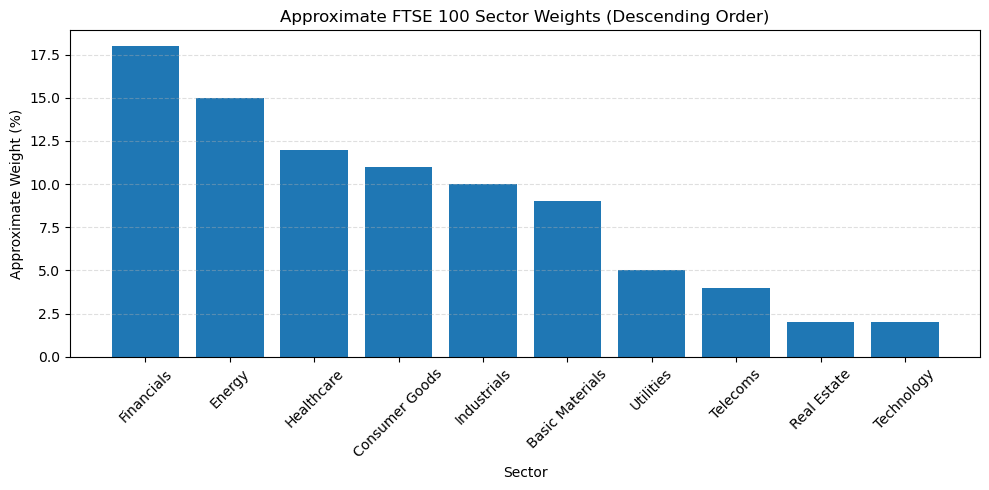

In [11]:
# Bar chart of FTSE 100 sector weights
sector_weights = majorSectors.copy()
sector_weights["Weight_num"] = (
    sector_weights["Approx Weight"]
    .str.replace("~", "", regex=False)
    .str.replace("%", "", regex=False)
    .astype(float)
)

sector_weights = sector_weights.sort_values("Weight_num", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(
    sector_weights["Sector"],
    sector_weights["Weight_num"]
)

plt.title("Approximate FTSE 100 Sector Weights (Descending Order)")
plt.ylabel("Approximate Weight (%)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

The results above show the approximate FTSE 100 sector weights in descending order, with Financials (\~18%), Energy (\~15%), and Healthcare (\~12%) representing the largest shares of the index. Therefore, these sectors have the greatest structural influence on overall FTSE 100 movements, as any changes in their performance are likely to have more noticeable index-level effects. However, we need to remember that companies also often enter and leave the FTSE 100, so these approximate weights could change.

When we talk about the 'most dominant' sectors, it highly depends on the context and what we are analysing. A higher index weight does not necessarily imply that a sector is the most influential during periods of crises. Sector influence is not static, but varies with different market sentiment and macroeconomic shocks.  While Financials and Energy account for a large proportion of the FTSE 100, smaller sectors such as Healthcare or Consumer Goods may exhibit greater resilience or defensive characteristics during economic downturns. Conversely, sectors with substantial weights may be more exposed to systemic shocks, amplifying market volatility during crisis periods. For example, the energy sector is shaped by global commodity price trends. Companies in this sector benefit when oil and gas prices rise, but they also face volatility from external influences ranging from geopolitical tensions to changing demand patterns.

This distinction motivates the central focus of this report: rather than defining dominance solely in terms of index composition, we examine which FTSE 100 sectors are most influenced by major crises, specifically Brexit and the COVID-19 pandemic. By analysing sector-level returns, volatility, and downside risk during these events, we aim to assess how different sectors respond to economic stress and to identify which sectors demonstrate resilience or vulnerability under crisis conditions.

### Stock Ticker Labels for Major Sector Companies in the FTSE 100 

In this section, we scrape company names, sectors, and tickersfrom the FTSE 100 Wikipedia page and cleaned to ensure consistent formatting. London Stock Exchange–specific ticker labels are then created for compatibility with Yahoo Finance. Finally, this information is merged with the previously identified major sector companies, allowing each firm to be accurately linked to its sector and corresponding price data for subsequent analysis.

In [12]:
#Wikipedia page with stock ticker label info
url = "https://en.wikipedia.org/wiki/FTSE_100_Index"
headers = {"User-Agent": "Mozilla/5.0"}

#Request the Wikipedia page
page = requests.get(url, headers=headers, timeout=10)
page.raise_for_status()

#Parse the HTML using BeautifulSoup
soup = BeautifulSoup(page.content, "lxml")

#Find the stock label table and extract into pandas df
tables = soup.find_all("table", {"class": "wikitable"})
tickerTable = tables[3]  
tickerDf = pd.read_html(StringIO(str(tickerTable)))[0]

#Make column names standard string format
tickerDf.columns = (
    tickerDf.columns.astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True))

#Get the info for the company, ticker and sector columns
company_col = [c for c in tickerDf.columns if "Company" in c][0]
ticker_col  = [c for c in tickerDf.columns if "Ticker" in c][0]
sector_col  = [c for c in tickerDf.columns if "FTSE industry" in c or "benchmark sector" in c][0]

tickerDf2 = tickerDf[[company_col, ticker_col, sector_col]].rename(
    columns={
        company_col: "Company",
        ticker_col: "Ticker",
        sector_col: "Sector"
    }
)
tickerDf3 = tickerDf2.copy()

#Create London Stock Exchange tickers for yfinance use later
tickerDf3["Ticker_L"] = tickerDf3["Ticker"].astype(str).str.strip() + ".L"

display(tickerDf3)

,Company,Ticker,Sector,Ticker_L
0,3i,III,Financial services,III.L
1,Admiral Group,ADM,Insurance,ADM.L
2,Airtel Africa,AAF,Telecommunications services,AAF.L
3,Alliance Witan,ALW,Investment Trusts,ALW.L
4,Anglo American plc,AAL,Mining,AAL.L
...,...,...,...,...
95,Unilever,ULVR,Personal goods,ULVR.L
96,United Utilities,UU,Multiline utilities,UU.L
97,Vodafone Group,VOD,Mobile telecommunications,VOD.L
98,Weir Group,WEIR,Industrial goods and services,WEIR.L


In [13]:
#Merge the data tables for ticker info and major FTSE100 sector companies
majorSectorsMerge = majorSectors2.merge(
    tickerDf3,
    left_on="Notable Companies",
    right_on="Company",
    how="left"
)

majorSectorsMerged = majorSectorsMerge.copy()
unmatched = majorSectorsMerged[majorSectorsMerged["Ticker"].isna()].copy()

#Fallback incase company didn't merge
for i, row in unmatched.iterrows():
    notable = row["Notable Companies"]
    pattern = rf"\b{re.escape(str(notable))}\b"
    candidates = tickerDf3[tickerDf3["Company"].str.contains(pattern, case=False, na=False)]
    
    if len(candidates) == 1:
        x = candidates.iloc[0]
        majorSectorsMerged.loc[i, "Company"] = x["Company"]
        majorSectorsMerged.loc[i, "Ticker"] = x["Ticker"]
        majorSectorsMerged.loc[i, "Ticker_L"] = x["Ticker_L"] 

#Add if the company was in the updated wikipedia sector label info table
majorSectorsMerged["Current_constituent"] = majorSectorsMerged["Ticker"].notna()
majorSectorsMerged.columns = ['Sector', 'Approx Weight', 'Notable Companies', 'Company', 'Ticker',
       'Sector_y', 'Ticker_L', 'Current_constituent']
display(majorSectorsMerged[["Sector", 'Approx Weight', "Notable Companies", "Ticker", "Ticker_L", "Current_constituent"]])

,Sector,Approx Weight,Notable Companies,Ticker,Ticker_L,Current_constituent
0,Energy,~15%,Shell,SHEL,SHEL.L,True
1,Energy,~15%,BP,BP,BP.L,True
2,Financials,~18%,HSBC,HSBA,HSBA.L,True
3,Financials,~18%,Lloyds,LLOY,LLOY.L,True
4,Financials,~18%,Barclays,BARC,BARC.L,True
5,Healthcare,~12%,AstraZeneca,AZN,AZN.L,True
6,Healthcare,~12%,GSK,GSK,GSK.L,True
7,Consumer Goods,~11%,Unilever,ULVR,ULVR.L,True
8,Consumer Goods,~11%,Diageo,DGE,DGE.L,True
9,Industrials,~10%,Rolls-Royce,RR,RR.L,True


### Historical Stock Data from Yahoo Finance

To analyze in subsequent section, we collect historical daily stock price data for companies in the FTSE 100 using Yahoo Finance. For each firm in the selected major sectors, adjusted daily prices are downloaded from 2010 onwards to ensure sufficient pre- and post-event coverage. Using adjusted prices allows returns to be comparable over time by accounting for dividends and stock splits. From these prices, daily percentage returns are computed and used as the primary input for subsequent descriptive analysis, event-window comparisons, and resilience modelling at the sector level. 

In [14]:
#Historical Stock Data Data Frame
companyTickers = " ".join(majorSectorsMerged["Ticker_L"].dropna().tolist())

#Import stock data starting from 2010
historicalData = yf.download(
    companyTickers,
    start="2010-01-01",
    end=datetime.today().strftime("%Y-%m-%d"),
    auto_adjust=True,
    group_by='ticker',
    progress=False
)

display(historicalData)

Ticker            DGE.L                                                    \
Price              Open         High          Low        Close     Volume   
Date                                                                        
2010-01-04  1080.095207  1082.086166  1069.144933  1078.104248  3128029.0   
2010-01-05  1074.122374  1078.104292  1057.199223  1058.194702  5016711.0   
2010-01-06  1060.185772  1065.163170  1053.217415  1055.208374  4899300.0   
2010-01-07  1055.208037  1068.149267  1053.217078  1062.176392  4623866.0   
2010-01-08  1062.176392  1067.153788  1058.194474  1062.176392  3078183.0   
...                 ...          ...          ...          ...        ...   
2026-01-22  1689.000000  1709.000000  1421.500000  1695.000000  5094480.0   
2026-01-23  1680.500000  1695.000000  1663.500000  1675.000000  4232414.0   
2026-01-26  1673.500000  1685.500000  1649.500000  1655.000000  4896119.0   
2026-01-27  1638.500000  1650.500000  1602.500000  1609.500000  4064591.0   
2026-01-28  1608.000000  1648.500000  1603.500000  1622.500000  5140730.0   

Ticker           SHEL.L                                                   ...  \
Price              Open         High          Low        Close    Volume  ...   
Date                                                                      ...   
2010-01-04  1867.111907  1915.215454  1863.144604  1915.215454   1595432  ...   
2010-01-05  1916.702867  1935.547553  1910.751914  1934.059814   2540289  ...   
2010-01-06  1922.653598  1929.100463  1912.239431  1914.718994   2676837  ...   
2010-01-07  1918.190890  1919.678629  1899.346202  1910.752197   3852745  ...   
2010-01-08  1910.752332  1912.240071  1878.022082  1894.387207   4972420  ...   
...                 ...          ...          ...          ...       ...  ...   
2026-01-22  2754.500000  2757.000000  2671.879883  2674.000000  11445467  ...   
2026-01-23  2686.000000  2722.000000  2678.000000  2687.500000   9909984  ...   
2026-01-26  2694.000000  2707.000000  2672.340088  2672.500000   7482122  ...   
2026-01-27  2672.500000  2700.004883  2666.000000  2697.000000  20289832  ...   
2026-01-28  2713.500000  2748.165039  2712.500000  2732.500000   7427780  ...   

Ticker            AAL.L                                                  \
Price              Open         High          Low        Close   Volume   
Date                                                                      
2010-01-04  2614.898141  2696.871516  2614.898141  2686.685303  4245050   
2010-01-05  2707.542490  2759.927967  2688.625687  2730.824951  3375486   
2010-01-06  2745.376577  2788.060972  2732.765455  2777.875000  4974570   
2010-01-07  2777.389436  2784.665129  2731.309887  2758.957520  4385814   
2010-01-08  2763.807645  2810.372314  2731.309474  2810.372314  3492027   
...                 ...          ...          ...          ...      ...   
2026-01-22  3405.000000  3451.000000  3298.000000  3342.000000  3057159   
2026-01-23  3327.000000  3434.000000  3321.000000  3378.000000  3606421   
2026-01-26  3398.000000  3484.000000  3378.000000  3448.000000  8610064   
2026-01-27  3443.000000  3475.000000  3394.000000  3449.000000  2710504   
2026-01-28  3532.000000  3555.000000  3446.000000  3476.000000  7250365   

Ticker            SGE.L                                                  
Price              Open         High          Low        Close   Volume  
Date                                                                     
2010-01-04   229.943390   238.424927   229.943390   238.424927  4298935  
2010-01-05   238.948490   238.948490   235.807133   237.482483  3556315  
2010-01-06   236.644852   237.796625   235.702422   236.644852  4144916  
2010-01-07   238.006022   241.461416   236.435396   240.414368  7763698  
2010-01-08   240.728577   241.461482   239.576713   240.728577  4754749  
...                 ...          ...          ...          ...      ...  
2026-01-22  1023.500000  1035.000000  1004.325012  1022.500000  68119

In [15]:
#Stock Price Change Data Frame
historicalData2 = yf.download(
    companyTickers,
    start="2010-01-01",
    end=datetime.today().strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False
)

#Convert price change to a percentage
closePrice = historicalData2["Close"]
percentChange = closePrice.pct_change(fill_method=None) * 100

display(percentChange[1:5])

Ticker,AAL.L,AZN.L,BA.L,BARC.L,BLND.L,BP.L,BT-A.L,DGE.L,GSK.L,HSBA.L,LAND.L,LLOY.L,NG.L,RIO.L,RR.L,SGE.L,SHEL.L,SSE.L,ULVR.L,VOD.L
Date,,,,,,,,,,,,,,,,,,,,
2010-01-05,1.642904,-1.139101,1.634323,6.255522,0.685530,1.059338,2.017309,-1.846718,-2.426245,1.445298,-0.965807,3.386921,0.220440,2.104064,0.162816,-0.395279,0.983929,0.601907,-2.154292,-0.139635
2010-01-06,1.722924,-1.117774,1.226518,2.985593,-2.574484,-0.112860,2.118658,-0.282210,-0.879863,0.461310,-0.675176,1.036447,-2.126123,2.568819,2.439022,-0.352713,-1.000011,0.512835,0.102375,-0.419304
2010-01-07,-0.681005,1.234799,0.026912,2.768722,0.174717,0.629617,-1.244815,0.660345,-0.154401,-0.526733,0.226574,4.286510,-2.247128,0.110057,-0.972185,1.592900,-0.207174,-1.445557,-1.227598,-2.596464
2010-01-08,1.863559,-0.068742,-0.807518,1.600640,0.588633,-0.256714,0.140020,0.000000,-0.966366,0.475225,0.075363,-0.052700,0.919479,0.027492,0.480859,0.130695,-0.856468,1.035340,0.258961,-1.296809


# Exploratory Analysis and Visualization

This section presents an exploratory analysis of FTSE 100 sector and company performance around the Brexit referendum and the COVID-19 crisis. Using descriptive statistics and visualizations of returns, cumulative returns, and volatility, we examine how different sectors and firms responded during periods of market stress. By comparing broad sector-level patterns with firm-level behaviour, and by focusing on event-window dynamics around each crisis, this analysis provides initial insights into cross-sector heterogeneity.

## Descriptive Statistics

,Mean,Standard Deviation,Minimum,1st Quartile (Q1),Median,3rd Quartile (Q3),Maximum,Skewness,Kurtosis
Sector,,,,,,,,,
Energy,0.000006,0.016506,-0.205126,-0.007818,0.000183,0.008260,0.190474,-0.432223,15.567315
Financials,0.000153,0.017466,-0.148214,-0.008418,0.000524,0.008726,0.122218,-0.357165,6.947101
Healthcare,0.000226,0.011969,-0.088679,-0.006128,0.000308,0.006926,0.083037,-0.210555,4.537817
Consumer Goods,0.000153,0.010756,-0.070996,-0.005709,0.000208,0.006308,0.071803,-0.090226,3.438626
Industrials,0.000453,0.017114,-0.121768,-0.007891,0.000547,0.008774,0.194558,0.407690,10.046236
Utilities,0.000169,0.011823,-0.111093,-0.005788,0.000472,0.006563,0.087732,-0.373152,7.043815
Telecoms,-0.000001,0.014299,-0.127946,-0.007661,0.000000,0.008027,0.088555,-0.299450,5.824376
Real Estate,-0.000024,0.016071,-0.193194,-0.008247,0.000302,0.008204,0.192718,-0.158374,14.250530
Technology,0.000352,0.015025,-0.143712,-0.006714,0.000765,0.008236,0.164444,-0.238447,11.298585


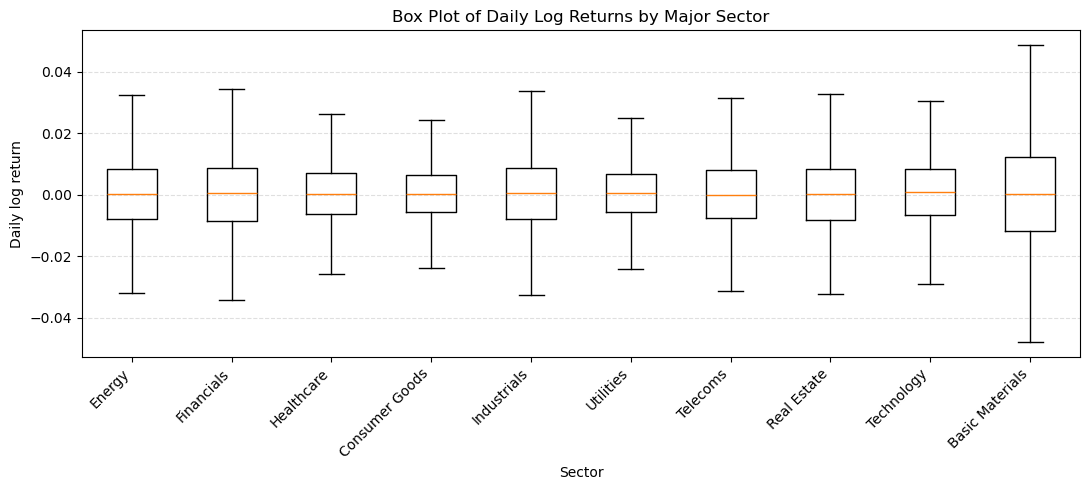

In [16]:
sector_map = (
    majorSectorsMerged[["Ticker_L", "Sector"]]
    .dropna(subset=["Ticker_L"])
    .drop_duplicates()
    .set_index("Ticker_L")["Sector"]
)

tickers_in_data = [t for t in sector_map.index if t in percentChange.columns]
sector_map = sector_map.loc[tickers_in_data]

logR = np.log1p(percentChange[tickers_in_data] / 100.0)
sectorLogR = logR.T.groupby(sector_map).mean().T
sector_order = majorSectors["Sector"].tolist()
sectorLogR = sectorLogR.reindex(columns=sector_order)
sector_stats = sectorLogR.describe().T.rename(columns={
    "mean": "Mean",
    "std": "Standard Deviation",
    "min": "Minimum",
    "25%": "1st Quartile (Q1)",
    "50%": "Median",
    "75%": "3rd Quartile (Q3)",
    "max": "Maximum"
})

sector_stats["Skewness"] = sectorLogR.skew()
sector_stats["Kurtosis"] = sectorLogR.kurtosis()

# select only the columns you want (so 'count' never appears)
sector_stats = sector_stats[["Mean", "Standard Deviation", "Minimum", "1st Quartile (Q1)", "Median", "3rd Quartile (Q3)","Maximum", "Skewness", "Kurtosis"]]

display(sector_stats)

# Box Plot of Sector Log Returns
data_for_box = []
for c in sectorLogR.columns:
    x = sectorLogR[c].values
    x = x[np.isfinite(x)]         
    data_for_box.append(x)

plt.figure(figsize=(11,5))
plt.boxplot(
    data_for_box,
    tick_labels=sectorLogR.columns,  
    showfliers=False
)
plt.title("Box Plot of Daily Log Returns by Major Sector")
plt.xlabel("Sector")
plt.ylabel("Daily log return")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

The above table and box plot summarizes the distribution of daily sector-level log returns for the 10 major FTSE 100 sectors. Across all sectors, the average daily log return is close to 0, which shows that the short-horizon returns are small relative to day-to-day variability. In contrast, the standard deviations are much larger than the means, confirming that volatility dominates daily movements.

Comparing sectors, Basic Materials exhibits the highest volatility and the widest spread in the box plot, consistent with its larger interquartile range and longer whiskers. Financials, Industrials and Energy also show relatively high dispersion, while Consumer Goods, Utilities and Healthcare display comparatively lower volatility and tighter box plots. Therefore, sectors with higher dispersion are more likely to contribute disproportionately to fluctuation in the overall FTSE 100, especially if these are among the most dominant by index weight.

For periods of financial stress or crisis, we would expect:
* Volatility to spike across all sectors, but especially in cyclical and macro-sensitive sectors such as Financials, Energy and Basic Materials.
* More extreme negative returns to occur more frequently (consistent with the negative skewness in several sectors).
* Heavier tails to become more pronounced: the high kurtosis values indicate that large moves are already more common than under a normal model, and crises typically amplify this, producing sharper drawdowns and occasional rebound days.

Overall, these descriptive statistics results highlight that even if mean returns are similar, the index’s behavior, especially during turbulent periods, will be largely shaped by its dominant sectors and their volatility and tail risk characteristics.

## Comparison of COVID-19 and Brexit Effects on Different Sectors and Companies

Building on this statistical characterization of volatility and returns, the following section turns to the realized behaviour of FTSE 100 sectors and firms. This section examines how major FTSE 100 sectors and companies responded to Brexit and COVID-19 by tracking cumulative returns over time. By aligning market movements around key event dates, the analysis provides a descriptive comparison of how these two economy-wide shocks translated into sector- and firm-level performance dynamics.

### Major FTSE 100 Sectors Gain/Loss Over Time - Returns and Cumulative Returns

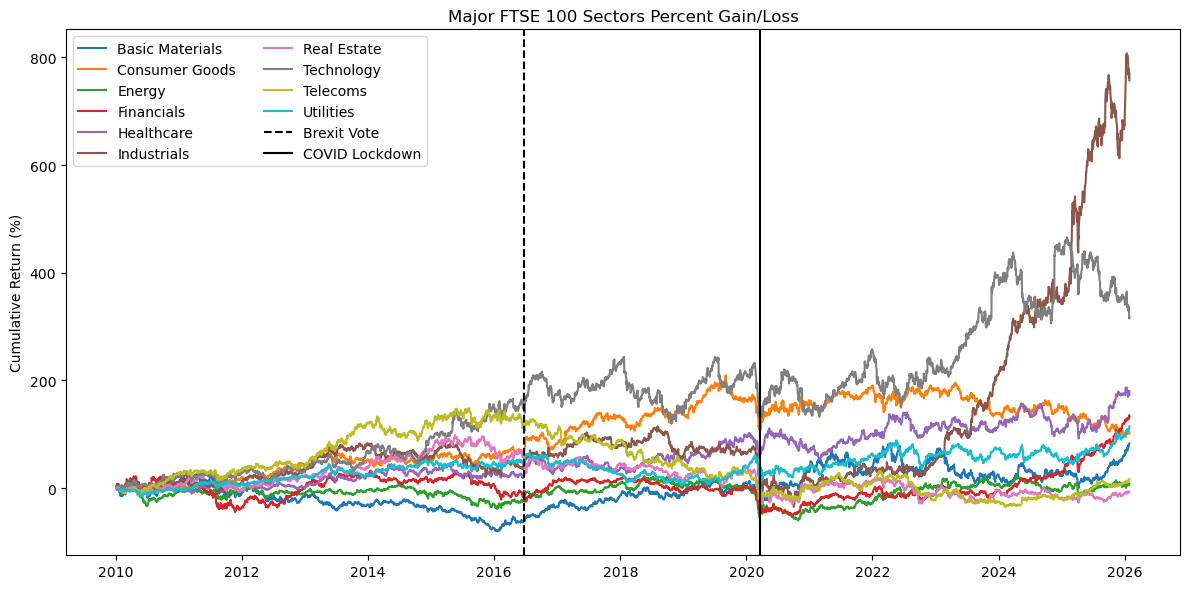

In [17]:
#Brexit Vote: June 23, 2016
#Official Leaving of EU: Jan 31, 2020
#Covid: March 1, 2020

brexitVote = pd.Timestamp('2016-06-23')
brexitOffical = pd.Timestamp('2020-01-31')
covidStart = pd.Timestamp('2020-03-23')

majorSectorsMerged2 = majorSectorsMerged.copy()

#Drop tickers, index by sector
sectorMapping = (majorSectorsMerged2
                 .dropna(subset=['Ticker_L']).set_index('Ticker_L')['Sector'])

#append tickers we have financial data for
sectorTs = []
for tick in sectorMapping.index:
    if tick in percentChange.columns:
        sectorTs.append(tick)

#drop any unused tickers
sectorMapping2 = sectorMapping.loc[sectorTs]
percentChange2 = percentChange[sectorTs]

#calculate average daily returns per sector
dailyReturnAvg = percentChange2.T.groupby(sectorMapping2).mean().T
dailyReturnAvg2 = ((1 + dailyReturnAvg / 100).cumprod()-1)* 100

#plot time series
plt.figure(figsize=(12,6))
for sector in dailyReturnAvg2.columns:
    plt.plot(dailyReturnAvg2.index, dailyReturnAvg2[sector], label=sector)
plt.axvline(brexitVote, linestyle="--", color="black", label="Brexit Vote")
plt.axvline(covidStart, linestyle="-", color="black", label="COVID Lockdown")
plt.title("Major FTSE 100 Sectors Percent Gain/Loss")
plt.ylabel("Cumulative Return (%)")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

From the aggregate plot, the Technology sector exhibits the strongest cumulative return performance prior to 2016 and clearly outperforms all other sectors over the full sample period, with particularly pronounced growth after 2020. The Industrials sector displays relatively steady cumulative returns until 2024, after which it experiences a sharp acceleration, briefly surpassing Technology around 2025. 

In contrast, traditional sectors such as Energy, Financials, and Basic Materials show comparatively low cumulative return growth over time. At this aggregate level, the effects of major crisis shocks are not immediately distinguishable, suggesting that long-run sectoral trends dominate short-term fluctuations in cumulative returns.

### Zoomed in Windows for FTSE 100 Cumulative Returns On Sector

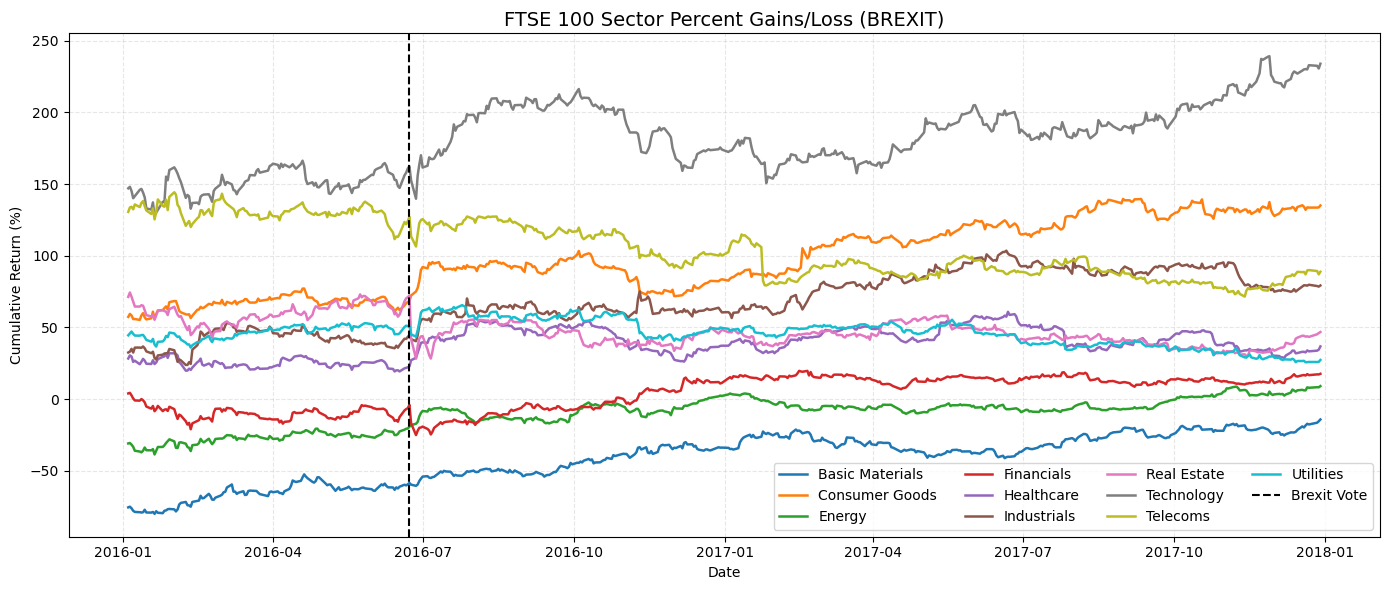

In [18]:
# Brexit Window from 2016 to 2017
start = pd.Timestamp("2016-01-01")
end   = pd.Timestamp("2017-12-31")
zoom = dailyReturnAvg2.loc[start:end]

plt.figure(figsize=(14,6))
for sector in zoom.columns:
    plt.plot(zoom.index, zoom[sector], linewidth=1.8, label=sector)
plt.axvline(brexitVote, linestyle="--", color="black", label="Brexit Vote")
plt.title("FTSE 100 Sector Percent Gains/Loss (BREXIT)", fontsize=14)
plt.ylabel("Cumulative Return (%)")
plt.xlabel("Date")
plt.legend(ncol=4)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Findings on Cumulative Returns Gains/Losses by Sector in Brexit**

When focusing on the zoomed time window surrounding the Brexit referendum, more informative sector-specific dynamics emerge. Overall, the immediate impact of Brexit on FTSE 100 sectoral cumulative returns appears modest in magnitude relative to longer-term trends.
* Several sectors, including Technology, Utilities, Financials, and Real Estate, experience small short-term declines following the referendum, though these movements are not dramatic.
* Notably, the Telecoms sector demonstrates relative resilience in the immediate post-referendum period, exhibiting limited drawdowns and rapid stabilization compared to more institutionally exposed sectors such as Financials and Real Estate.
* Technology and Consumer Goods display a brief upward adjustment shortly after the shock, with Technology continuing to trend upward over time, suggesting limited sensitivity to Brexit-related uncertainty.
* In contrast, the Real Estate sector recovers only partially, potentially reflecting prolonged uncertainty surrounding the United Kingdom’s future relationship with the European Union, particularly with respect to migration and cross-border investment.

Together, these patterns suggest that Brexit operated primarily as a sector-specific shock rather than a uniform market-wide disruption.

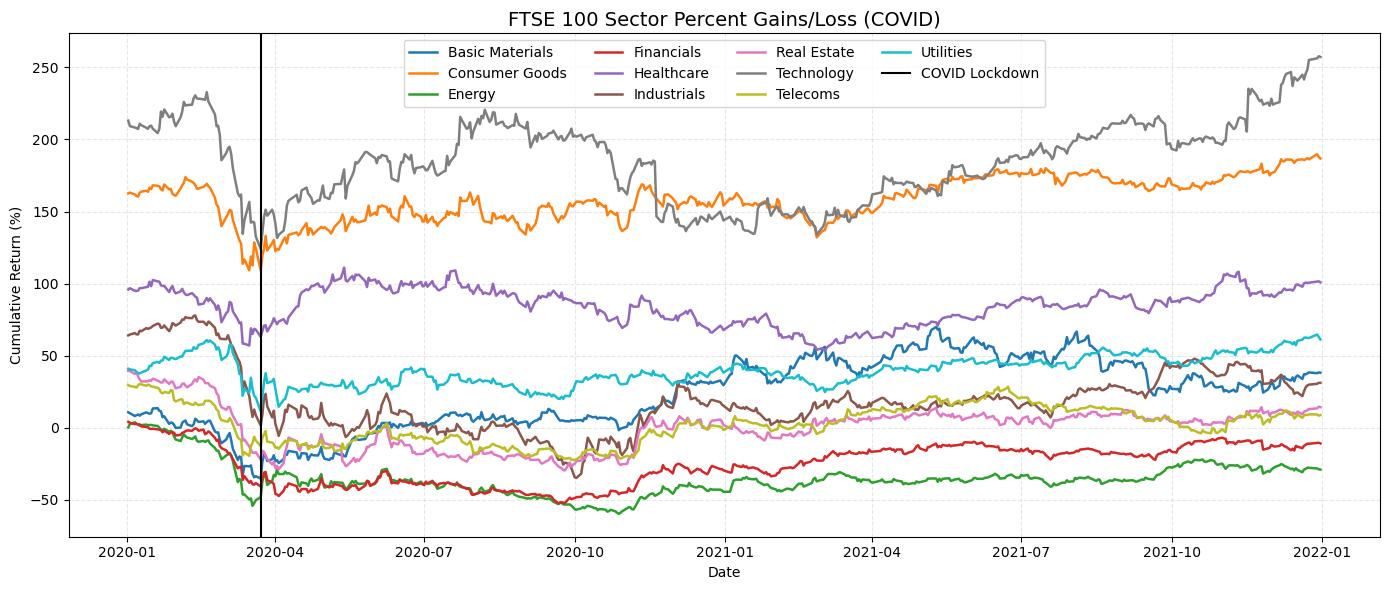

In [19]:
# COVID Window from 2020 to 2021
start = pd.Timestamp("2020-01-01")
end   = pd.Timestamp("2021-12-31")
zoom = dailyReturnAvg2.loc[start:end]

plt.figure(figsize=(14,6))
for sector in zoom.columns:
    plt.plot(zoom.index, zoom[sector], linewidth=1.8, label=sector)
plt.axvline(covidStart, linestyle="-", color="black", label="COVID Lockdown")
plt.title("FTSE 100 Sector Percent Gains/Loss (COVID)", fontsize=14)
plt.ylabel("Cumulative Return (%)")
plt.xlabel("Date")
plt.legend(ncol=4)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Findings on Cumulative Returns Gains/Losses by Sector in COVID-19**

The COVID-19 zoomed window presents a markedly different dynamic. In contrast to Brexit, all sectors experience a simultaneous and sharp decline during the onset of the pandemic, consistent with a systemic shock. However, the magnitude of the decline varies substantially across sectors. 
* Energy, Financials, and Real Estate suffer the steepest declines. They remain depressed for a prolonged period, indicating more persistent negative effects for capital-intensive sectors and those incompatible with lockdown conditions.
* Technology, Consumer Goods, and Healthcare experience comparatively smaller drops and quicker recoveries, reflecting compatibility with remote work, digital demand, and pandemic-related consumption patterns.
* During the recovery phase, Technology rebounds rapidly and exceeds pre-pandemic levels before 2022, while Consumer Goods also exhibit a strong recovery by late 2020.

These patterns suggest that while COVID-19 acted as a common shock across sectors, recovery trajectories were highly sector-dependent. While Brexit induced sector-specific shocks related to institutional exposure and political uncertainty, COVID-19 generated a common shock whose long-run effects were mediated by the adaptability and growth of specific sectors sectors. 

While sector-level trends highlight broad patterns of resilience and underperformance, they may conceal substantial heterogeneity across individual firms. To examine whether sectoral performance is driven by uniform firm behavior or by a small number of dominant companies, the analysis now turns to firm-level cumulative returns.

### Major FTSE 100 Companies Gain/Loss Over Time - Returns and Cumulative Returns

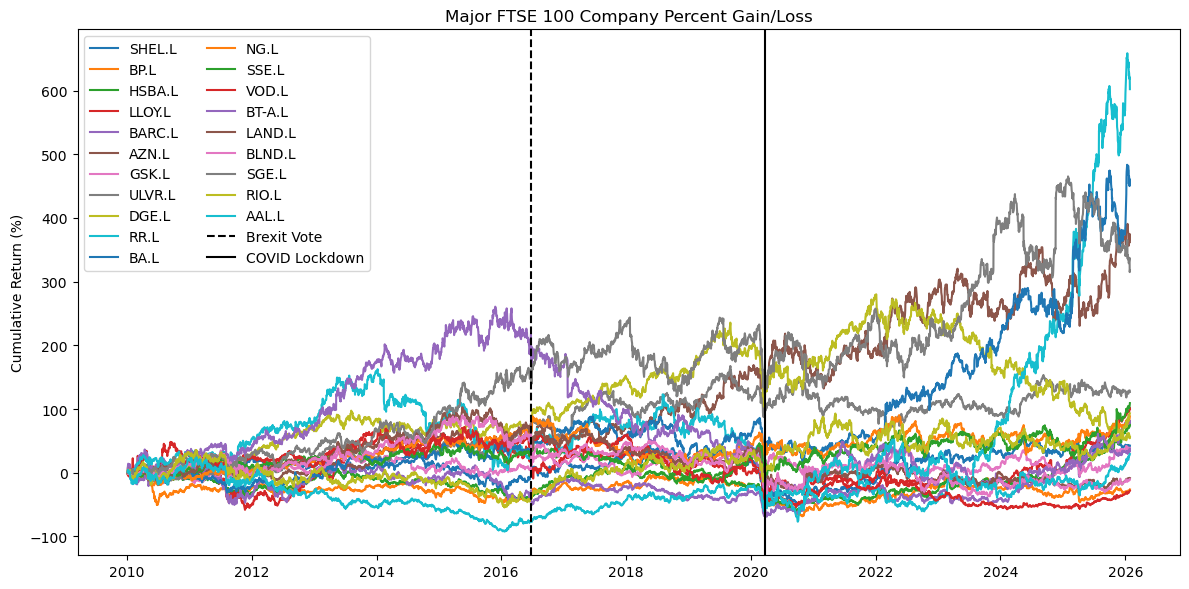

In [20]:
#Get list of company tickers
companyTs = (majorSectorsMerged.dropna(subset=['Ticker_L'])["Ticker_L"].unique().tolist())
companyTs2 = []

#filter tickers that exist in percent change financial data
for tick in companyTs:
    if tick in percentChange.columns:
        companyTs2.append(tick)

#filter companies we have financial data for
companyChanges = percentChange[companyTs2]
changesPercent = ((1 + companyChanges / 100).cumprod()-1)* 100

#plot time series for % gain or loss per company
plt.figure(figsize=(12,6))
for c in changesPercent.columns:
    plt.plot(changesPercent.index, changesPercent[c], label=c)
plt.axvline(brexitVote, linestyle="--", color="black", label="Brexit Vote")
plt.axvline(covidStart, linestyle="-", color="black", label="COVID Lockdown")
plt.title("Major FTSE 100 Company Percent Gain/Loss")
plt.ylabel("Cumulative Return (%)")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

From the aggregate company level plot, cumulative return performance varies substantially across FTSE 100 firms, with long-run outcomes dominated by a small subset of companies. A few firms, such as Sage, AstraZeneca, Diageo, and RELX, exhibit sustained upward trajectories over the full sample period, while many others remain flat or experience prolonged drawdowns.

At this level, the effects of Brexit and COVID-19 are not sharply distinguishable, indicating that company specific fundamentals and long-run growth paths dominate short-term crisis shocks. This highlights substantial within sector variation, where sector level trends mask meaningful differences in company level resilience and long-run performance.

### Zoomed in Windows for FTSE 100 Company Percent Gain/Loss

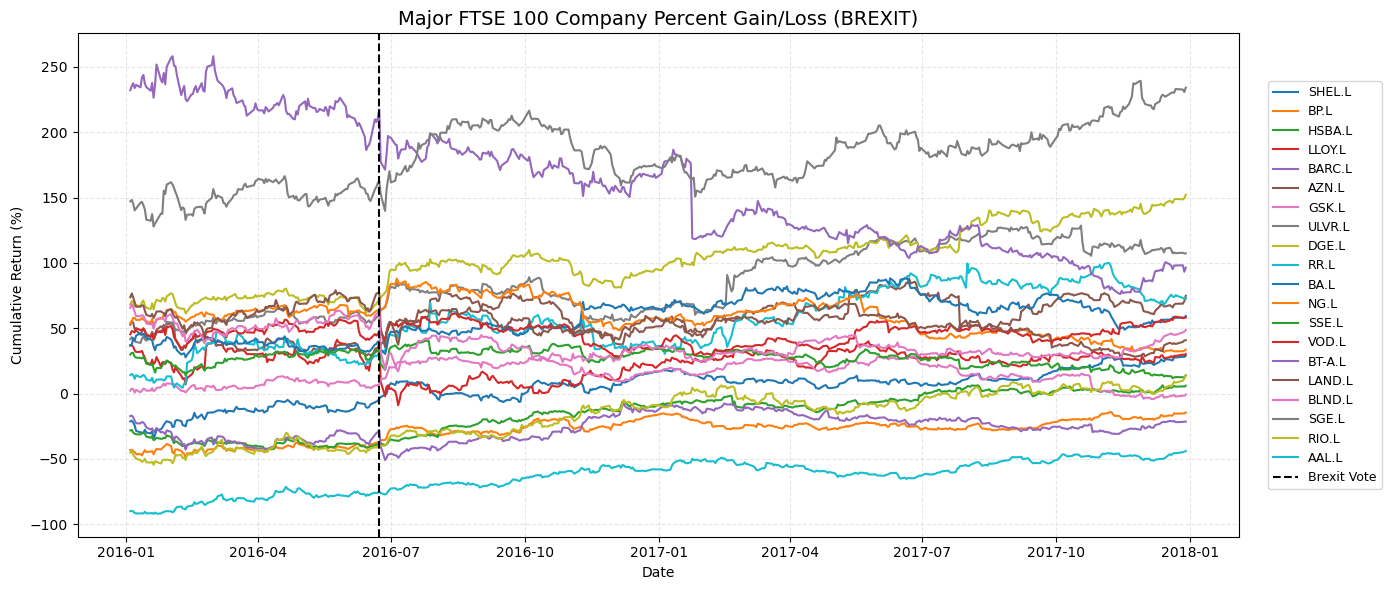

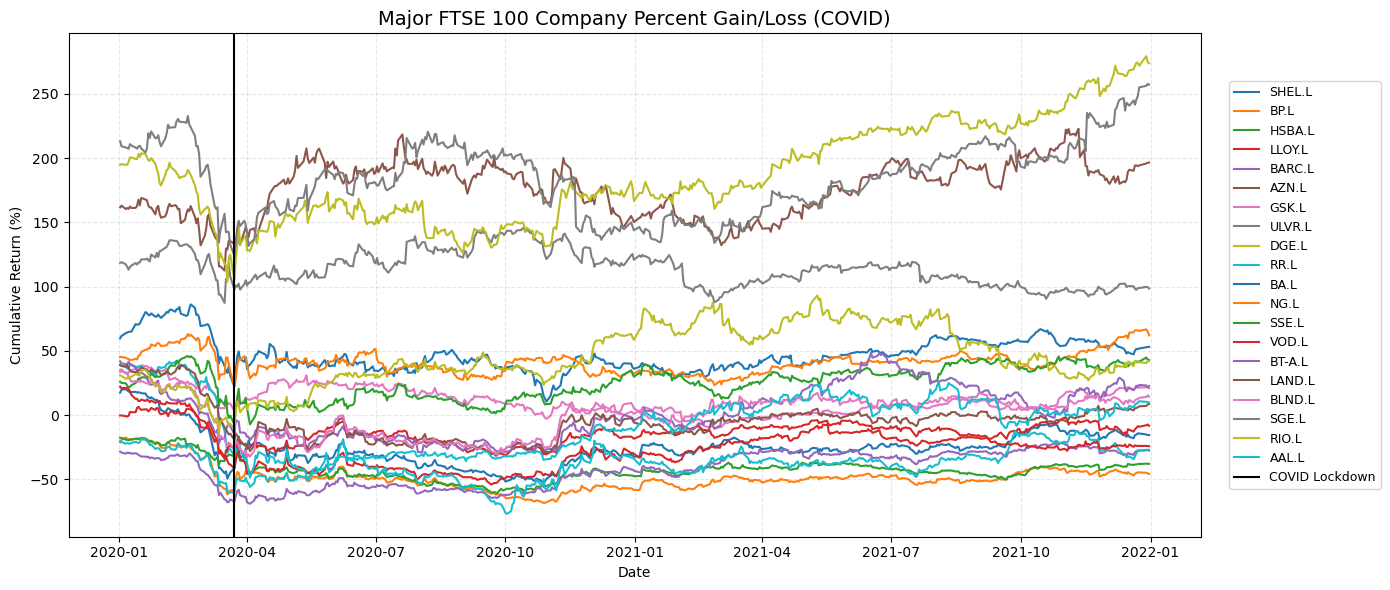

In [21]:
# Zoomed in Brexit Window
start = pd.Timestamp("2016-01-01")
end   = pd.Timestamp("2017-12-31")
zoom_comp = changesPercent.loc[start:end]

plt.figure(figsize=(14,6))
for c in zoom_comp.columns:
    plt.plot(zoom_comp.index, zoom_comp[c], linewidth=1.5, label=c)
plt.axvline(brexitVote, linestyle="--", color="black", label="Brexit Vote")
plt.title("Major FTSE 100 Company Percent Gain/Loss (BREXIT)", fontsize=14)
plt.ylabel("Cumulative Return (%)")
plt.xlabel("Date")
plt.legend(
    ncol=1,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


# Zoomed in COVID Window
start = pd.Timestamp("2020-01-01")
end   = pd.Timestamp("2021-12-31")
zoom_comp = changesPercent.loc[start:end]

plt.figure(figsize=(14,6))
for c in zoom_comp.columns:
    plt.plot(zoom_comp.index, zoom_comp[c], linewidth=1.5, label=c)
plt.axvline(covidStart, linestyle="-", color="black", label="COVID Lockdown")
plt.title("Major FTSE 100 Company Percent Gain/Loss (COVID)", fontsize=14)
plt.ylabel("Cumulative Return (%)")
plt.xlabel("Date")
plt.legend(
    ncol=1,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Findings on Cumulative Returns Gains/Losses by Company**

* Unilever (ULVR.L) and Diageo (DGE.L): <br>
 Display limited declines in cumulative returns during both crisis windows and recover rapidly, reflecting their exposure to global consumer demand and the upward recovery seen in the Consumer Goods sector prior. Particularly resilient to both Brexit and COVID shocks.
* RELX (REL.L): <br>
 Shows notable resilience, with comparatively muted declines and strong post-shock growth, consistent with its digital-driven growth, as explained in the Technology sector trends. 
* Energy and Financials (BP (BP.L), Shell (SHEL.L), HSBC (HSBA.L), and Lloyds (LLOY.L)): <br>
 Experience sharper declines and more prolonged recoveries, particularly during the COVID-19 period. This suggests that company-level resilience is closely tied to sectoral characteristics rather than individually unique firm effects alone. 

Resilience to major shocks is concentrated among firms with global exposure and stable demand. Yet, the top performing company does not necessarily align with the top performing sector, indicating that sector leadership does not imply uniform company level success. Instead, aggregate sector performance masks substantial within-sector company viaration, with a small number of resilient and well-positioned firms accounting for a disproportionate share of long-run gains.

The COVID shock is abrupt and uniform across firms but variation emerges quickly in the post-lockdown period, indicating that recovery dynamics, not initial exposure, drive long-run firm performance.

## Which sectors were most volatile in crisis periods?

Cumulative returns summarize the direction and persistence of performance following Brexit and COVID, but they may mask fluctuations in uncertainty that occur around these events. Because financial crises often manifest more strongly through spikes in volatility than through sustained losses, the cumulative returns analysis is complemented with a rolling volatility heatmap to capture changes in volatility (risk) across sectors over time.

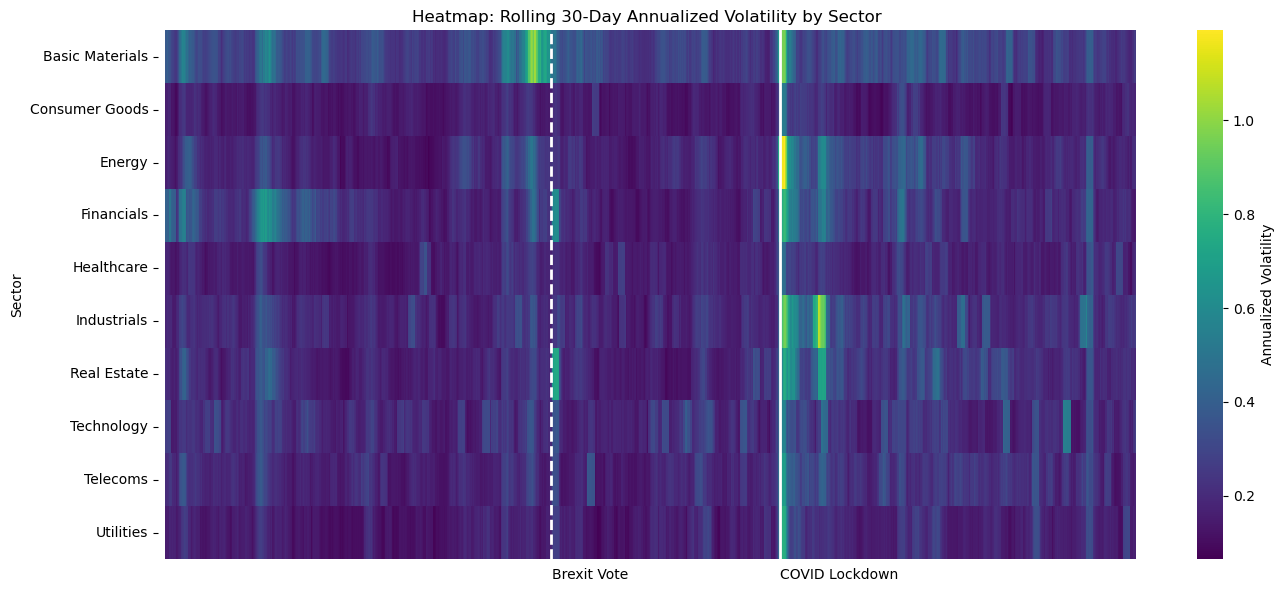

In [22]:
import seaborn as sns

window = 30

# Rolling 30-day annualized volatility for each sector
# Volatility of stocks from the finance formula of volatility = standard deviation of returns
rolling_vol = (dailyReturnAvg/100).rolling(window).std() * np.sqrt(252)

# Heatmap data where sectors as rows and date is columns
heat = rolling_vol.T

# Plotting heatmap
plt.figure(figsize=(14,6))
volatility_heat = sns.heatmap(
    heat,
    cmap="viridis",
    xticklabels=False,
    yticklabels=True,
    cbar_kws={"label": "Annualized Volatility"}
)

plt.title(f"Heatmap: Rolling {window}-Day Annualized Volatility by Sector")
volatility_heat.set_xlabel("") # Remove x-axis label

# Find closest column positions for covid and brexit events
brexit_col = np.argmin(np.abs(rolling_vol.index - brexitVote))
covid_col  = np.argmin(np.abs(rolling_vol.index - covidStart))

# Adding event lines to heatmap
volatility_heat.axvline(brexit_col, color="white", linestyle="--", linewidth=2)
volatility_heat.axvline(covid_col, color="white", linestyle="-", linewidth=2)

# Add labels to the event lines
volatility_heat.text(brexit_col + 1, 10.3, "Brexit Vote", color="black", fontsize=10, ha="left", va="center")
volatility_heat.text(covid_col + 1, 10.3, "COVID Lockdown", color="black", fontsize=10, ha="left", va="center")

plt.tight_layout()
plt.show()

**Sectoral Volatility Responses to Brexit and COVID**

* Brexit: <br>
Volatility increases are modest and sector-specific. Financials and Real Estate exhibit noticeable but contained spikes, while Technology, Consumer Goods, Healthcare, and Utilities show muted responses, indicating limited exposure to Brexit-related uncertainty. Interestingly, it is apparent that the Basic Materials sector is inherently  more volatile than other sectors and experiences more intense volatility leading up to Brexit rather than after. 

* COVID-19: <br>
Volatility spikes sharply and simultaneously across all sectors, consistent with a systemic shock. Energy, Industrials, Financials, and Real Estate experience the largest and most persistent increases, whereas Consumer Goods, Healthcare, and Utilities display more shorter-lived spikes.

Financials emerge as the most volatile sector across both Brexit and COVID, exhibiting the most volatility when accounting for both crises. Consumer Goods and Healthcare emerge as the least volatile for both based on the heatmap, showcasing a resilience to systemic and institutional shocks.

## Cumulative Return Responses in ±30- and ±60-Day Event Windows

The volatility heatmap identifies sharp, time-localized spikes in uncertainty around Brexit and COVID. Motivated by these dynamics, the company-level cumulative return changes over ±30- and ±60-day windows are examined to capture both immediate market reactions and short-term adjustment following each shock. This section examines how individual FTSE 100 companies' cumulative returns evolve within ±30- and ±60-day windows around the Brexit referendum and COVID-19 lockdown.

,Brexit Impact (±30 days),Brexit Impact (±60 days)
Ticker,,
BT-A.L,-46.57,-28.56
LLOY.L,-34.33,-23.84
BLND.L,-23.51,-6.64
BARC.L,-11.44,-4.42
RIO.L,11.56,1.51
LAND.L,-16.52,2.84
SSE.L,7.16,3.50
AAL.L,6.05,3.70
VOD.L,6.01,3.82


<Figure size 1000x800 with 0 Axes>

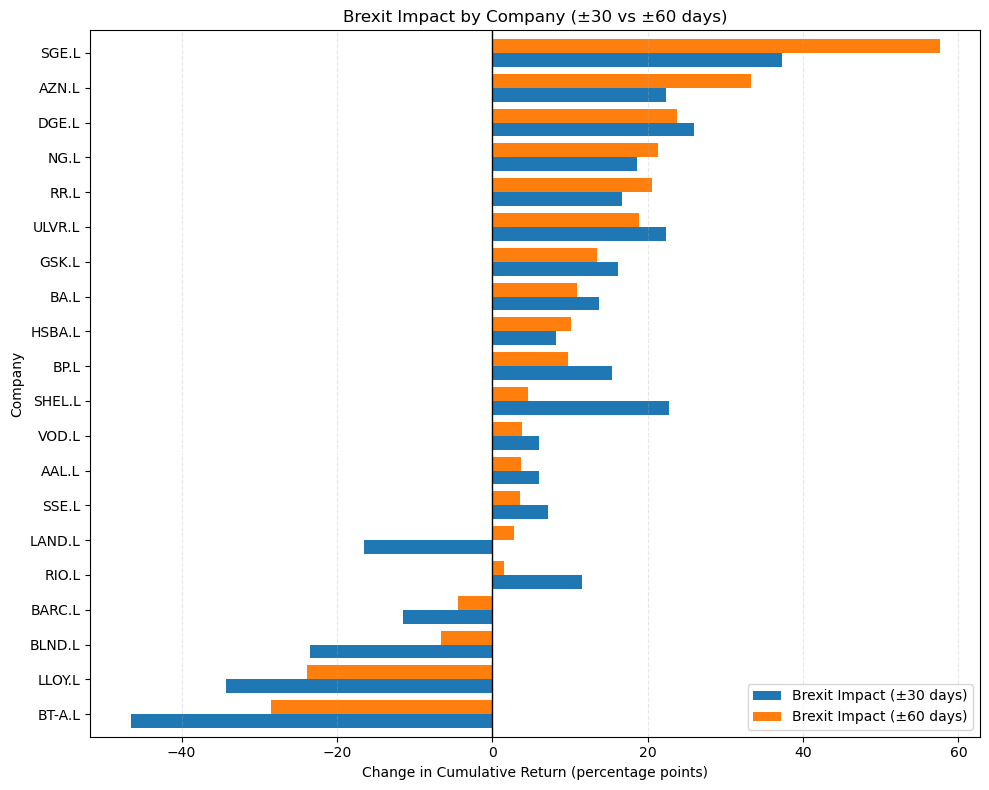

In [23]:
# Brexit Short and Longer Term Shock 

# Window of 60 days before Brexit event and 60 days after
pre_brexit_60  = changesPercent.loc[:brexitVote - pd.Timedelta(days=60)].iloc[-1]
post_brexit_60 = changesPercent.loc[:brexitVote + pd.Timedelta(days=60)].iloc[-1]
brexit_impact_60_companies = (post_brexit_60 - pre_brexit_60)

# Window of 30 days before Brexit event and 30 days after
pre_brexit_30  = changesPercent.loc[:brexitVote - pd.Timedelta(days=30)].iloc[-1]
post_brexit_30 = changesPercent.loc[:brexitVote + pd.Timedelta(days=30)].iloc[-1]
brexit_impact_30_companies = (post_brexit_30 - pre_brexit_30)

# Combine both window results into one table
brexit_company_compare = pd.DataFrame({
    "Brexit Impact (±30 days)": brexit_impact_30_companies,
    "Brexit Impact (±60 days)": brexit_impact_60_companies
}).sort_values("Brexit Impact (±60 days)", ascending=True).round(2)

display(brexit_company_compare)

# Bar chart visualization
plt.figure(figsize=(10,8))
ax = brexit_company_compare.plot(kind="barh", figsize=(10,8), width=0.8)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Brexit Impact by Company (±30 vs ±60 days)")
ax.set_xlabel("Change in Cumulative Return (percentage points)")
ax.set_ylabel("Company")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Brexit: Short vs. Longer Window Effects**

Brexit effects vary widely at the company level, even within the same sector:
* **Largest losers**: BT, Lloyds, Barclays, and British Land experience substantial negative cumulative return changes, particularly over ±30 days, reflecting exposure to domestic regulation and institutional uncertainty.
* **Resilient firms**: Sage, AstraZeneca, Diageo, and Unilever remain positive across both windows, with gains often increasing by ±60 days, consistent with the resilience of Technology, Healthcare, and Consumer Goods sectors.
* **Adjustment over time**: Several firms show partial recovery in the ±60-day window, indicating that Brexit effects unfolded gradually rather than as a sharp one-day shock.

,COVID Impact (±30 days),COVID Impact (±60 days)
Ticker,,
RR.L,-67.91,-75.82
LAND.L,-45.79,-57.99
LLOY.L,-48.78,-56.15
BLND.L,-37.39,-49.51
SHEL.L,-26.18,-45.81
BA.L,-44.13,-40.32
BT-A.L,-28.46,-39.95
DGE.L,-40.86,-35.44
SGE.L,-63.08,-31.01


<Figure size 1000x600 with 0 Axes>

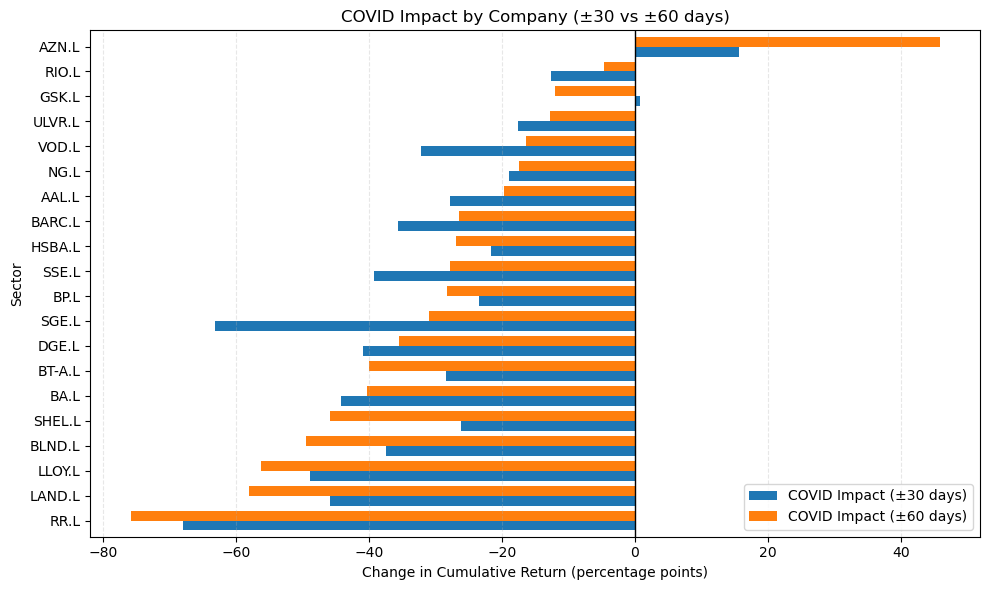

In [24]:
# Covid Short and Longer Term Shock 

# Window of 60 days before COVID event and 60 days after 
pre_covid_60  = changesPercent.loc[:covidStart - pd.Timedelta(days=60)].iloc[-1]
post_covid_60 = changesPercent.loc[:covidStart + pd.Timedelta(days=60)].iloc[-1]
covid_impact_60 = (post_covid_60 - pre_covid_60)

# Window of 30 days before COVID event and 30 days after 
pre_covid_30  = changesPercent.loc[:covidStart - pd.Timedelta(days=30)].iloc[-1]
post_covid_30 = changesPercent.loc[:covidStart + pd.Timedelta(days=30)].iloc[-1]
covid_impact_30 = (post_covid_30 - pre_covid_30)

# Combine both window results into one table with columns
covid_compare = pd.DataFrame({
    "COVID Impact (±30 days)": covid_impact_30,
    "COVID Impact (±60 days)": covid_impact_60
}).sort_values("COVID Impact (±60 days)", ascending=True).round(2)

display(covid_compare)

# Bar chart Visualization of Windows in COVID
covid_plot = covid_compare.copy()

plt.figure(figsize=(10,6))
covid_plot.plot(kind="barh", figsize=(10,6), width=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.title("COVID Impact by Company (±30 vs ±60 days)")
plt.xlabel("Change in Cumulative Return (percentage points)")
plt.ylabel("Sector")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**COVID-19: Short vs Longer Window Effects**

During COVID shocks, most companies experience substantial losses in both windows, with the ±60 day impacts generally more severe.

* Largest and most persistent losses are observed for Rolls-Royce (RR.L), Land Securities (LAND.L), Lloyds (LLOY.L), British Land (BLND.L), and energy firms such as Shell (SHEL.L), reflecting exposure to mobility restrictions, capital intensity, and financial stress.
* Financials and real estate show deep drawdowns with limited short-run recovery, indicating prolonged sensitivity to lockdown conditions.
* Defensive and healthcare firms are comparatively resilient. AstraZeneca (AZN.L) is the only firm with positive cumulative returns over both windows, while firms such as Unilever (ULVR.L) and Diageo (DGE.L) experience smaller declines and faster stabilization.

# Modeling

We have already explored FTSE 100 sector behavior during the  Brexit referendum and the COVID-19 crisis using descriptive statistics and visual analysis. These results highlighted clear differences in sector-level returns, volatility, drawdowns, and recovery patterns across both events. In this section, we will introduce a modeling based analysis that builds on previous data. Our aim is to summarize the dominant patterns in sector behaviour during crisis periods.

To achieve this, we apply principal component analysis (PCA) and k-means clustering to sector-level resilience metrics for both Brexit and COVID-19. We use PCA to reduce dimensionality and highlight the main sources of variation in sector responses. The method of k-means clustering helps us to group sectors with similar crisis behaviour. Together, these help us to assess whether sector resilience is consistent across different market shocks or varies depending on the nature of the crisis.

### Principal Component Analysis (PCA) on resilience metrics (Brexit vs COVID-19)

In [25]:
dailyReturnAvg_log = np.log1p(dailyReturnAvg / 100)   
dailyReturnAvg2_log = dailyReturnAvg_log.cumsum()     

# Crisis event dates + modelling windows (by index positions)
def nearest_trading_day(idx, target_date):
    idx = pd.DatetimeIndex(idx)
    return idx[np.argmin(np.abs(idx - target_date))]

def window_slice(df, event_day, w):
    idx = df.index
    i0 = idx.get_loc(event_day)
    i_start = max(i0 - w, 0)
    i_end = min(i0 + w, len(idx) - 1)
    return df.iloc[i_start:i_end+1], idx[i_start], idx[i_end]

event_dates = {
    "Brexit": nearest_trading_day(dailyReturnAvg_log.index, brexitVote),
    "COVID":  nearest_trading_day(dailyReturnAvg_log.index, covidStart)
}
windows = [30, 60]
crisis_windows = {}
summary = []

for event_name, event_day in event_dates.items():
    crisis_windows[event_name] = {}
    for w in windows:
        ret_slice, start, end = window_slice(dailyReturnAvg_log, event_day, w)
        cum_slice, _, _ = window_slice(dailyReturnAvg2_log, event_day, w)
        crisis_windows[event_name][f"pm{w}"] = {
            "event_day": event_day,
            "start": start,
            "end": end,
            "returns": ret_slice,
            "cum_returns": cum_slice
        }
        summary.append([event_name, f"±{w} trading days", start, event_day, end])
window_summary = pd.DataFrame(summary, columns=["Event", "Window", "Start", "Event Day (aligned)", "End"])

# Build sector "resilience" feature tables for Brexit and COVID (±30, ±60 trading days)

# Max drawdown from cumulative log returns (dailyReturnAvg2_log is cumsum of log returns)
def max_drawdown_from_cumlog(cumlog_series):
    cl = cumlog_series - cumlog_series.iloc[0]
    wealth = np.exp(cl.values)
    peak = np.maximum.accumulate(wealth)
    dd = wealth / peak - 1.0
    return np.min(dd)

# Feature builder for one event (Brexit or COVID)
def build_features_for_event(event_name):
    features = {}
    for w in [30, 60]:
        info = crisis_windows[event_name][f"pm{w}"]
        R = info["returns"]      
        C = info["cum_returns"]  
        impact = (C.iloc[-1] - C.iloc[0]).rename(f"Impact (±{w}d, cum log)")
        vol = R.std().rename(f"Volatility (±{w}d, std)")
        worst_day = R.min().rename(f"Worst Day (±{w}d)")
        mdd = pd.Series({s: max_drawdown_from_cumlog(C[s]) for s in C.columns},
                        name=f"Max Drawdown (±{w}d)")
        feat_w = pd.concat([impact, vol, worst_day, mdd], axis=1)
        features[f"pm{w}"] = feat_w
    features_all = features["pm30"].merge(features["pm60"], left_index=True, right_index=True)
    return features_all

# Build tables
features_brexit = build_features_for_event("Brexit")
features_covid  = build_features_for_event("COVID")
print("Brexit: Sector Resilience Metrics (±30d and ±60d)")
display(features_brexit)
print("COVID-19: Sector Resilience Metrics (±30d and ±60d)")
display(features_covid)

Brexit: Sector Resilience Metrics (±30d and ±60d)


,"Impact (±30d, cum log)","Volatility (±30d, std)",Worst Day (±30d),Max Drawdown (±30d),"Impact (±60d, cum log)","Volatility (±60d, std)",Worst Day (±60d),Max Drawdown (±60d)
Basic Materials,0.248760,0.027262,-0.050143,-0.106154,0.375614,0.032578,-0.115213,-0.241823
Consumer Goods,0.125806,0.011772,-0.017828,-0.060158,0.114914,0.010512,-0.018884,-0.090556
Energy,0.116064,0.014744,-0.036900,-0.114892,0.142474,0.014420,-0.036900,-0.118053
Financials,-0.037756,0.029688,-0.143512,-0.219839,0.070482,0.023539,-0.143512,-0.219839
Healthcare,0.206901,0.012635,-0.022396,-0.062274,0.208187,0.011676,-0.022396,-0.085509
Industrials,0.111113,0.015917,-0.028178,-0.063070,0.070504,0.014041,-0.028178,-0.109449
Real Estate,-0.062979,0.035446,-0.192901,-0.259217,-0.099246,0.026408,-0.192901,-0.259217
Technology,0.177800,0.017754,-0.051860,-0.094071,0.161348,0.014906,-0.051860,-0.099692
Telecoms,-0.005063,0.016300,-0.062191,-0.131755,-0.062636,0.012859,-0.062191,-0.131755
Utilities,0.051968,0.014703,-0.040233,-0.062130,0.049486,0.012166,-0.040233,-0.069432


COVID-19: Sector Resilience Metrics (±30d and ±60d)


,"Impact (±30d, cum log)","Volatility (±30d, std)",Worst Day (±30d),Max Drawdown (±30d),"Impact (±60d, cum log)","Volatility (±60d, std)",Worst Day (±60d),Max Drawdown (±60d)
Basic Materials,-0.251253,0.047351,-0.166143,-0.390479,-0.084971,0.037131,-0.166143,-0.429414
Consumer Goods,-0.134058,0.025290,-0.070797,-0.227265,-0.022471,0.020331,-0.070797,-0.236248
Energy,-0.408965,0.057472,-0.205059,-0.511828,-0.451033,0.044154,-0.205059,-0.558166
Financials,-0.508217,0.041609,-0.135078,-0.471302,-0.498459,0.034327,-0.135078,-0.494273
Healthcare,0.064781,0.024350,-0.088647,-0.187829,0.004029,0.019806,-0.088647,-0.224443
Industrials,-0.548607,0.045681,-0.120340,-0.469465,-0.404538,0.038115,-0.120340,-0.474020
Real Estate,-0.415065,0.036768,-0.117667,-0.473614,-0.458441,0.033328,-0.122569,-0.493421
Technology,-0.209410,0.028599,-0.109815,-0.326957,-0.089572,0.023813,-0.109815,-0.326957
Telecoms,-0.285063,0.033944,-0.127931,-0.322112,-0.322552,0.028147,-0.127931,-0.386143
Utilities,-0.169155,0.035912,-0.111051,-0.307484,-0.013092,0.027927,-0.111051,-0.307484


To compare sector resilience across the two crises, we summarize each of the 10 major FTSE 100 sectors using crisis-window 'resilience metrics'. For each event, metrics are computed over symmetric windows of ±30 and ±60 trading days using sector-level daily log returns and their cumulative sums. For each sector and window length, we define:
* **Impact**: The net cumulative log return across the event window. Impacts are generally small and often positive around Brexit, whereas for COVID-19, they are negative for almost all sectors.
* **Volatility**: Dispersion of daily log returns within the window. Volatility is noticeably higher during COVID-19 than Brexit across every sector.
* **Worst Day**:The most negative single-day faily log return in the window. The worst single-day losses are substantially more severe in COVID-19 and contain sharper one-day shocks.
* **Maximum Drawdown**: The deepest peak-to-trough decline within the window based on cumulative return path. Max drawdowns are deeper in COVID-19, so it is more persistent before recovering.


Brexit - Explained Variance


,PC,Explained Variance Ratio,Cumulative
0,PC1,0.719741,0.719741
1,PC2,0.250914,0.970656
2,PC3,0.013333,0.983988
3,PC4,0.008524,0.992512
4,PC5,0.005847,0.998359
5,PC6,0.000830,0.999189
6,PC7,0.000773,0.999962
7,PC8,0.000038,1.000000



Brexit - Loadings (PC1 & PC2)


,PC1,PC2
"Impact (±30d, cum log)",0.267491,0.521703
"Volatility (±30d, std)",-0.403254,0.158300
Worst Day (±30d),0.402836,0.132771
Max Drawdown (±30d),0.401071,0.110972
"Impact (±60d, cum log)",0.156631,0.640425
"Volatility (±60d, std)",-0.321867,0.435212
Worst Day (±60d),0.411585,-0.088673
Max Drawdown (±60d),0.381007,-0.255748


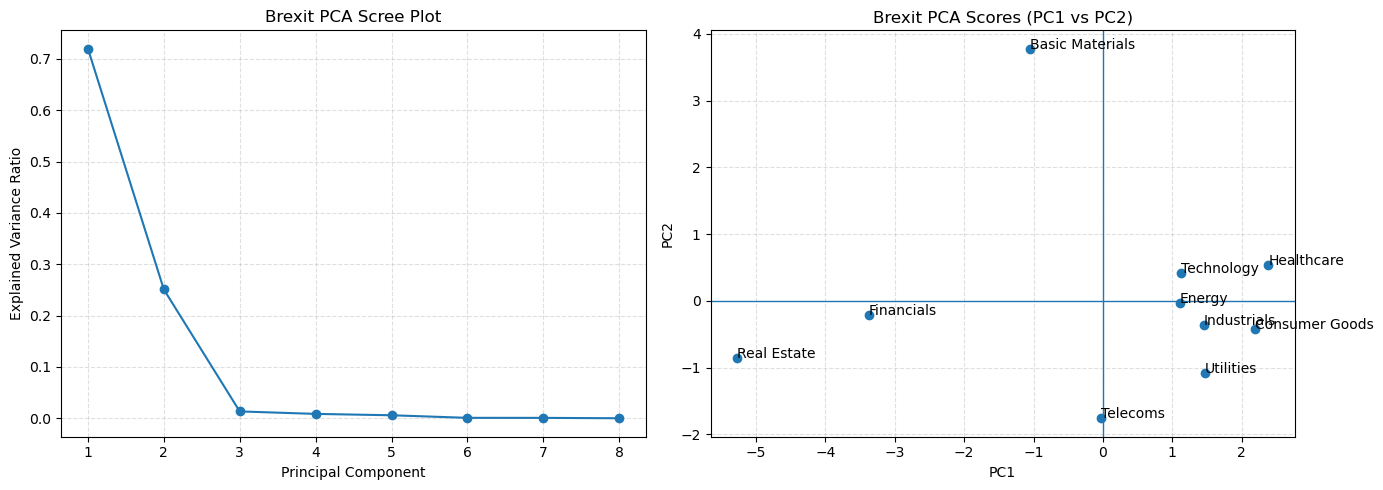


COVID-19 - Explained Variance


,PC,Explained Variance Ratio,Cumulative
0,PC1,0.833315,0.833315
1,PC2,0.131027,0.964342
2,PC3,0.023768,0.988109
3,PC4,0.006468,0.994578
4,PC5,0.004623,0.999201
5,PC6,0.000737,0.999938
6,PC7,0.000050,0.999988
7,PC8,0.000012,1.000000



COVID-19 - Loadings (PC1 & PC2)


,PC1,PC2
"Impact (±30d, cum log)",0.329466,0.472967
"Volatility (±30d, std)",-0.364829,0.253671
Worst Day (±30d),0.337199,-0.460619
Max Drawdown (±30d),0.372109,0.213824
"Impact (±60d, cum log)",0.319025,0.475674
"Volatility (±60d, std)",-0.378375,0.107223
Worst Day (±60d),0.340561,-0.444165
Max Drawdown (±60d),0.381126,0.137902


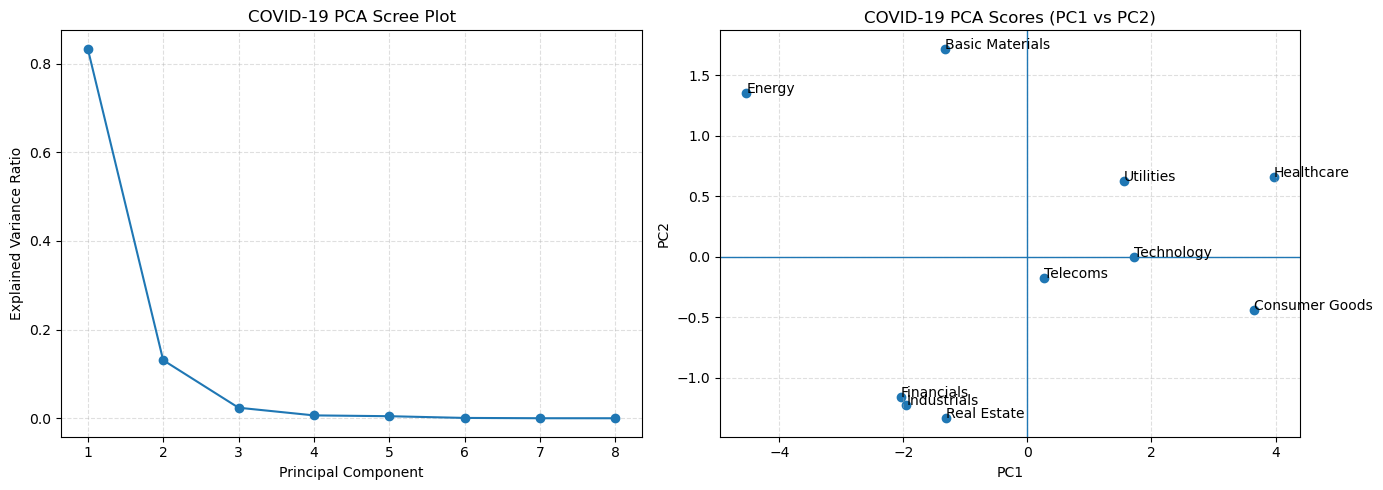

In [26]:
# PCA with side-by-side plots and tables
def pca_side_by_side_with_tables(features_df, title_prefix=""):
    sectors = features_df.index.tolist()
    feat_names = features_df.columns.tolist()
    X_std = StandardScaler().fit_transform(features_df.values)
    pca = PCA()
    scores = pca.fit_transform(X_std)
    evr = pca.explained_variance_ratio_

    #Explained variance table
    explained = pd.DataFrame({
        "PC": [f"PC{i+1}" for i in range(len(feat_names))],
        "Explained Variance Ratio": evr,
        "Cumulative": np.cumsum(evr)
    })
    print(f"\n{title_prefix} - Explained Variance")
    display(explained)

    # Loadings (PC1 & PC2)
    loadings = pd.DataFrame(
        pca.components_.T,
        index=feat_names,
        columns=[f"PC{i+1}" for i in range(len(feat_names))]
    )
    print(f"\n{title_prefix} - Loadings (PC1 & PC2)")
    display(loadings[["PC1", "PC2"]])

    # Scree and Scores plots
    plt.figure(figsize=(14,5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(feat_names)+1), evr, marker="o")
    plt.title(f"{title_prefix} PCA Scree Plot")
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.grid(True, linestyle="--", alpha=0.4)
    
    plt.subplot(1, 2, 2)
    plt.scatter(scores[:,0], scores[:,1])
    for i, s in enumerate(sectors):
        plt.text(scores[i,0], scores[i,1], s)
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.title(f"{title_prefix} PCA Scores (PC1 vs PC2)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return explained, loadings, scores

expl_brexit, load_brexit, scores_brexit = pca_side_by_side_with_tables(features_brexit, "Brexit")
expl_covid, load_covid, scores_covid = pca_side_by_side_with_tables(features_covid, "COVID-19")

To summarize and visualize differences in sector resilience during each crisis, we apply PCA to the sector-level resilient metrics from the previous section. PCA reduces these correlated measures into a small number of orthogonal components, allowing us to identify the main dimensions along which sectors differ and to visualize sector similarity in a low-dimensional space (PC1-PC2).

#### Brexit Results
For Brexit, the scree plot indicates a strong low-dimensional structure: PC1 explains ~72% of total variation and PC2 explains ~25%, so the first two components capture almost all cross-sector differences. The loadings suggest that PC1 is driven by downside-risk intensity, with relatively large contributions from the worst-day and maximum drawdown measures in both ±30 and ±60 windows. So, PC1 larely separates sectors by how severe their adverse outcomes were around the Brexit vote.

The PC1–PC2 score plot shows clear sector separation: 
* **Defensive/Resilient Sectors**: Healthcare, Consumer Goods, Utilities (and to a degree Technology) appear relatively more resilient around Brexit in our results because they sit in the main cluster on the positive side of PC1. This indicates that these sectors experienced less severe downside risk and more favourable cumulative return outcomes following the Brexit referendum. This behaviour is consistent with economic expectations, in that defensive sectors are typically those with demand that is less sensitive to the business cycle so they tend to hold up better in stress periods. 
* **Crisis-Sensitive Sectors**: Financials and Real Estate appear on the negative side of PC1, indicating higher volatility, larger drawdowns, and worse single-day losses during the crisis window. Financial institutions are directly exposed to uncertainties such as regulation and interest rates, both of which were central concerns following Brexit. Similarly, Real Estate is sensitive to expectations about economic growth and investment confidence, particularly after a major political event such as Brexit. 
* **Cyclical Sectors**: Industrials and Energy sit within the broader positive-PC1 cluster but do not appear as “strongly defensive” leaders. This intermediate positioning is consistent with cyclical exposure: these sectors are sensitive to growth expectations and risk sentiment, so their response to Brexit can be mixed, affected by uncertainty initially, but not necessarily exhibiting the most persistent downside profile among all sectors.
* **Outlier**: Basic Materials emerges as a clear outlier, particularly along PC2. The key reason is that it's dominated by globally exposed commodity producers, so returns are driven more by commodity prices and overseas demand than UK-specific policy uncertainty. After the referendum, sterling’s depreciation likely boosted GBP-denominated returns for firms with substantial foreign revenues. Together, these global and FX-translation effects help explain why Basic Materials behaves idiosyncratically and separates from the other sector clusters.

#### COVID-19 Results
Applying the same PCA framework to sector-level resilience metrics during the COVID-19 crisis reveals both similarities and important differences compared to the Brexit event. As before, PC1 captures overall crisis severity and downside risk, while PC2 reflects cumulative return impact and recovery direction. For COVID-19, PC1 explains ~83% of total variation and PC2 ~13% (≈96% cumulatively), indicating that sector behaviour during the pandemic can also be effectively summarized in a low-dimensional space.

The PC1–PC2 score plot highlights clear grouping:
* **Defensive/Resilient Sectors**: Healthcare and Consumer Goods sit far on the positive side of PC1, indicating comparatively better crisis outcomes (higher impact, smaller downside metrics). Utilities and Technology also lie on the positive side, consistent with their defensive qualities (Utilities) and stay-at-home / digital demand tailwinds (Technology) during the pandemic period. This pattern is broadly in line with how markets often treat these sectors as more resilient when uncertainty spikes and spending patterns shift.
* **Crisis-Sensitive Sectors**: Financials, Industrials, and Real Estate cluster on the negative side of PC1, suggesting more severe downside outcomes (more negative impact and deeper drawdowns). These sectors were directly impacted by lockdowns, supply chain disruptions, reduced economic activity, changes in macro and investment activity, making them among the most crisis-sensitive during COVID-19.
* **Outliers**: Energy is positioned far to the left (strongly negative PC1) and also separated along PC2, indicating an especially severe and distinct shock profile. This aligns with the sharp collapse in global activity and oil demand in early 2020, which hit energy producers disproportionately. Basic Materials sits noticeably away from the main cluster (high on PC2), suggesting a response pattern that differs from most sectors. Similar to Brexit, this reflects commodity-cycle dynamics and global demand conditions that can diverge from the domestic/lockdown-driven shock.


#### Comparison

Overall, the PCA results suggest that COVID-19 created a more uniform “single-shock” separation across sectors than Brexit. Under COVID, PC1 explains a much larger share of variation (~83% vs ~72%), indicating that most cross-sector differences can be summarized along one dominant resilience dimension. The COVID-19 PCA results are broadly consistent with economic intuition and market commentary, highlighting the importance of essential services and demand inelasticity during systemic health shocks. Unlike Brexit, which primarily generated financial and policy uncertainty, COVID-19 caused a direct disruption to production and consumption. This difference is reflected in the stronger relative performance of Healthcare and Utilities, and the heightened vulnerability of Industrials and Real Estate. 

### K-Means Clustering on Resilience Metrics (Brexit vs COVID)

Brexit - Chosen k = 3


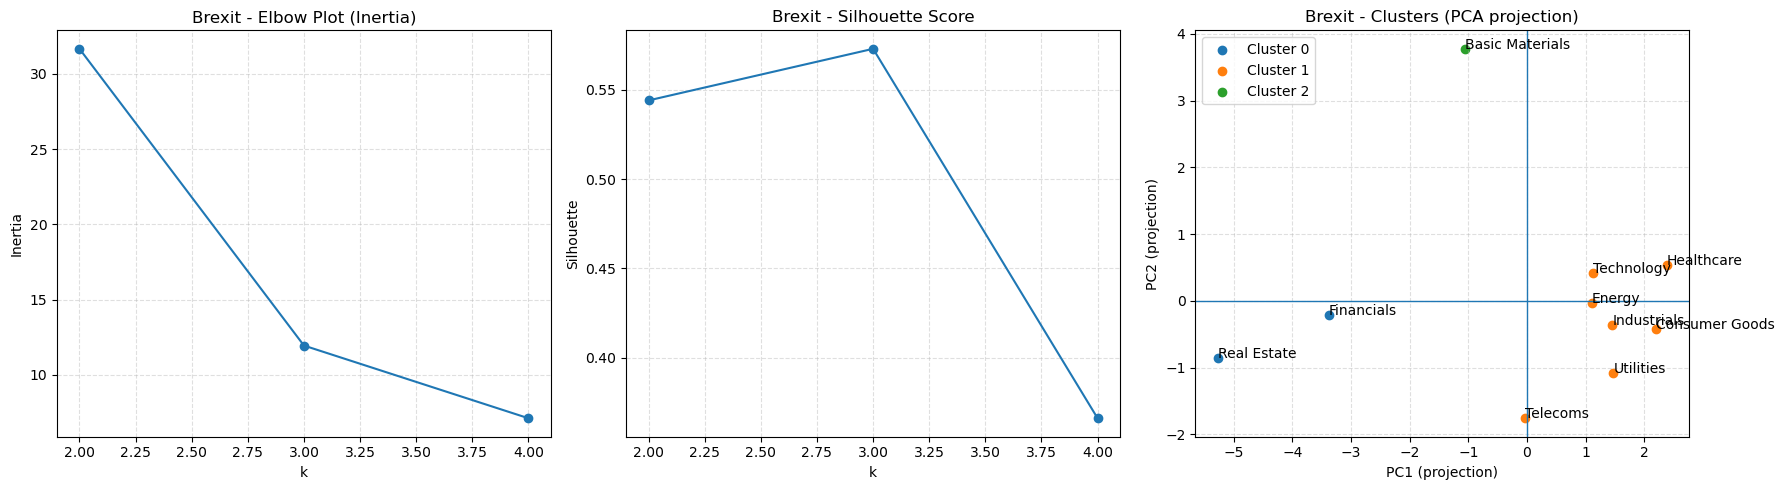

COVID - Chosen k = 2


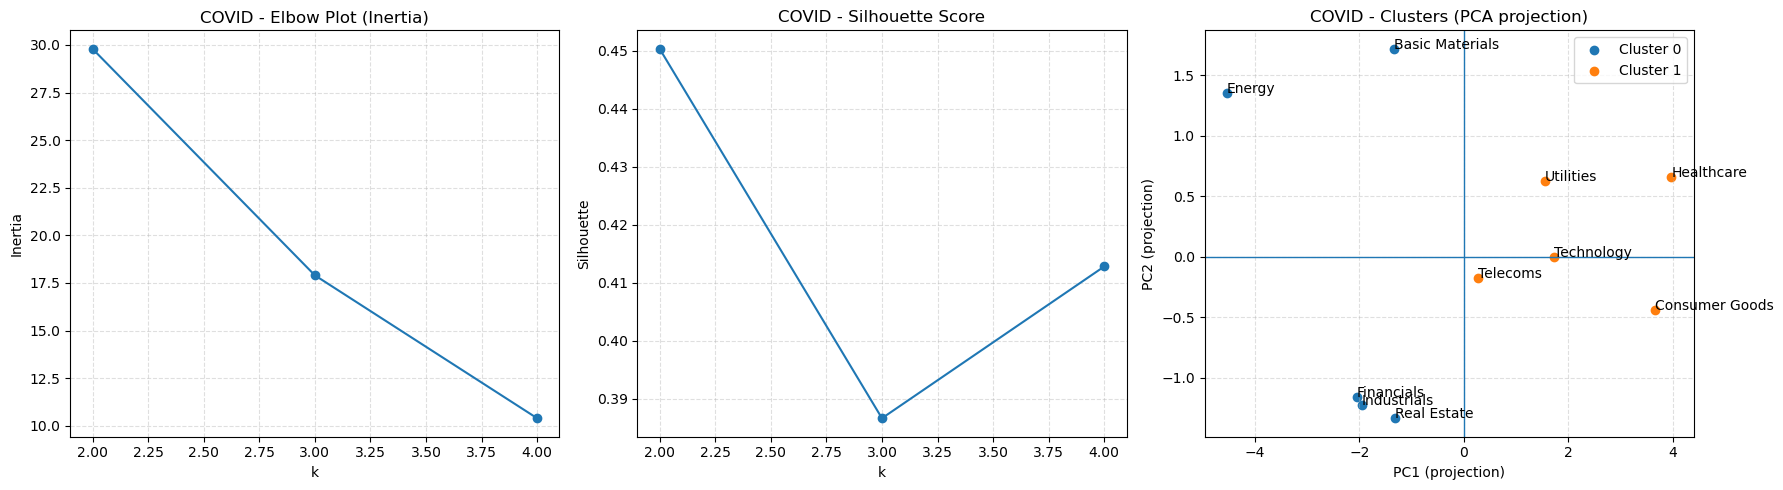

In [27]:
def kmeans_one_row(features_df, title_prefix="", k_min=2, k_max=4):
    X = features_df.values
    sectors = features_df.index.tolist()
    X_std = StandardScaler().fit_transform(X)

    ks = list(range(k_min, k_max+1))
    inertias, sils = [], []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(X_std)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X_std, labels))

    # Choose best k by silhouette
    k_best = ks[int(np.argmax(sils))]
    km_final = KMeans(n_clusters=k_best, random_state=42, n_init=50)
    cluster_labels = km_final.fit_predict(X_std)

    clusters = pd.DataFrame({"Cluster": cluster_labels}, index=sectors).sort_values("Cluster")
    print(f"{title_prefix} - Chosen k = {k_best}")
    
    # PCA projection for plotting clusters
    pca2 = PCA(n_components=2)
    Z = pca2.fit_transform(X_std)

    plt.figure(figsize=(18,5))

    # Elbow
    plt.subplot(1, 3, 1)
    plt.plot(ks, inertias, marker="o")
    plt.title(f"{title_prefix} - Elbow Plot (Inertia)")
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.grid(True, linestyle="--", alpha=0.4)

    # Silhouette
    plt.subplot(1, 3, 2)
    plt.plot(ks, sils, marker="o")
    plt.title(f"{title_prefix} - Silhouette Score")
    plt.xlabel("k")
    plt.ylabel("Silhouette")
    plt.grid(True, linestyle="--", alpha=0.4)

    # Cluster plot
    plt.subplot(1, 3, 3)
    for c in sorted(np.unique(cluster_labels)):
        mask = cluster_labels == c
        plt.scatter(Z[mask,0], Z[mask,1], label=f"Cluster {c}")
        for i in np.where(mask)[0]:
            plt.text(Z[i,0], Z[i,1], sectors[i])
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.title(f"{title_prefix} - Clusters (PCA projection)")
    plt.xlabel("PC1 (projection)")
    plt.ylabel("PC2 (projection)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return clusters, k_best

clusters_brexit, k_brexit = kmeans_one_row(features_brexit, "Brexit", k_min=2, k_max=4)
clusters_covid, k_covid = kmeans_one_row(features_covid, "COVID", k_min=2, k_max=4)

To complement the PCA visualization, we apply k-means clustering to the standardized resilience metrics, to group sectors with similar crisis behaviour in an unsupervised way. We choose the number of clusters k using both the elbow plot (inertia) and the silhouette score.

#### Brexit
For Brexit, the elbow curve shows a clear improvement when moving from k=2 to k=3, with smaller gains thereafter, while the silhouette score peaks at  k=3 (around 0.6). This supports selecting three clusters as a reasonable balance between separation and interpretability. The resulting clusters reveal clear and economically meaningful groupings:
* **Cluster 0 (Crisis-sensitive)**: Financials and Real Estate
    * This cluster contains Financials and Real Estate, both of which exhibit high volatility, large drawdowns, and poor cumulative return performance during the Brexit period. These sectors were particularly exposed to Brexit-related uncertainty surrounding regulation, capital flows, interest rates, and investment confidence.
* **Cluster 1 (Moderately Resilient / Cyclical Sectors)**: Consumer Goods, Energy, Healthcare, Industrials, Technology, Telecoms, and Utilities
    * Most sectors fall into one cluster, suggesting that despite differences in sign and magnitude of impacts, their resilience profiles are not sharply separable at this feature scale. These sectors experienced varying degrees of short-term stress but did not suffer the extreme downside observed in the crisis-sensitive cluster. This grouping reflects a mix of defensive and cyclical behaviour, where sector performance depended on underlying demand stability, global exposure, and the ability to absorb uncertainty. The breadth of this cluster highlights that Brexit affected many sectors, but with less severe and more heterogeneous impacts t
* **Cluster 2 (Outliere)**: Basic Materials
    * Basic Materials forms its own cluster, indicating distinctly different behaviour from all other sectors. Its response to Brexit was strongly influenced by global commodity prices and international demand rather than domestic political uncertainty alone, justifying its separation into a standalone cluster.

The k-means clustering aligns closely with the PCA-based interpretation. Crisis-sensitive sectors identified along negative PC1 scores are grouped together, moderately resilient sectors cluster around the origin of the PCA space, and Basic Materials consistently emerges as an outlier. This consistency strengthens confidence in the robustness of the identified sector classifications. Taken together, the PCA and k-means results suggest that Brexit generated a heterogeneous shock across sectors, with clustering driven primarily by exposure to financial and regulatory uncertainty rather than a single dominant crisis dimension.

#### Covid-19
For Covid-19, we apply k-means to the standardised COVID-19 resilience metrics and select the number of clusters using the elbow plot (inertia) and the silhouette score. While inertia keeps decreasing as k increases, the silhouette score is maximised at k=2 (≈0.45) and drops for k=3, indicating that two clusters provide the clearest separation in this sample. ence, with k=2, the sector groupings are:
* **Cluster 0 (Crisis-sensitive)**: Basic Materials, Energy, Financials, Industrials, Real Estate
    * The common feature across these sectors is their strong exposure to real economic activity and global demand. Lockdowns, supply chain disruptions, and sharp contractions in investment and consumption directly affected industrial production, property markets, commodity demand, and financial intermediation. As a result, these sectors exhibit a shared vulnerability profile and are grouped together by the clustering algorithm.
* **Cluster 1 (Moderately Resilient / Defensive Sectors)**: Consumer Goods, Healthcare, Technology, Telecoms and Utilities
    * This grouping reflects the importance of essential demand and operational continuity during the pandemic. Healthcare and utilities benefited from inelastic demand, consumer goods maintained stable consumption patterns, and technology and telecoms were supported by the rapid shift to remote working and digital services. Their separation into a distinct cluster highlights their comparatively defensive behaviour during COVID-19.

The two-cluster structure aligns closely with the PCA analysis. Sectors with strongly negative PC1 scores, associated with higher downside risk and volatility, are grouped into the crisis-sensitive cluster, while sectors with more moderate or positive resilience characteristics form the defensive cluster. The emergence of only two clusters further supports the interpretation that COVID-19 acted as a broad, systemic shock, producing a more uniform separation across sectors than Brexit.

Overall, the COVID-19 clustering results indicate a clear binary split between economically exposed sectors and defensive, essential-demand sectors. This contrasts with the Brexit case, where sector responses were more heterogeneous and required a richer clustering structure. The findings reinforce the conclusion that sector resilience depends strongly on the nature of the crisis, with COVID-19 amplifying differences based on real-economy exposure rather than financial or regulatory uncertainty alone.

### Overall Resilience Score by Sector

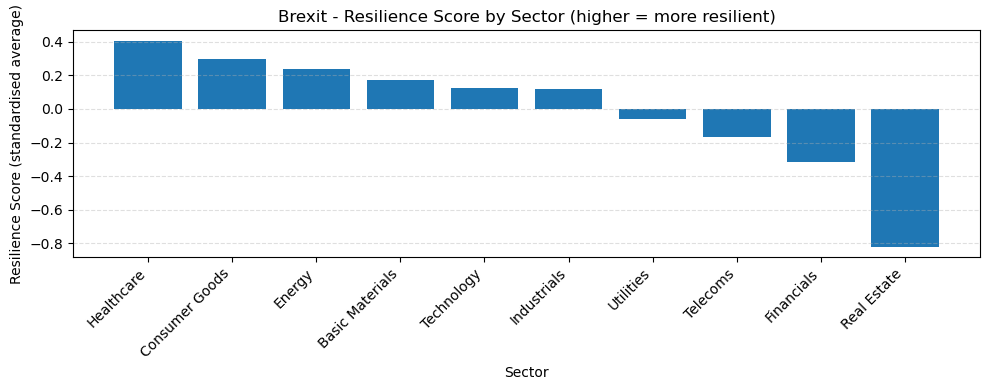

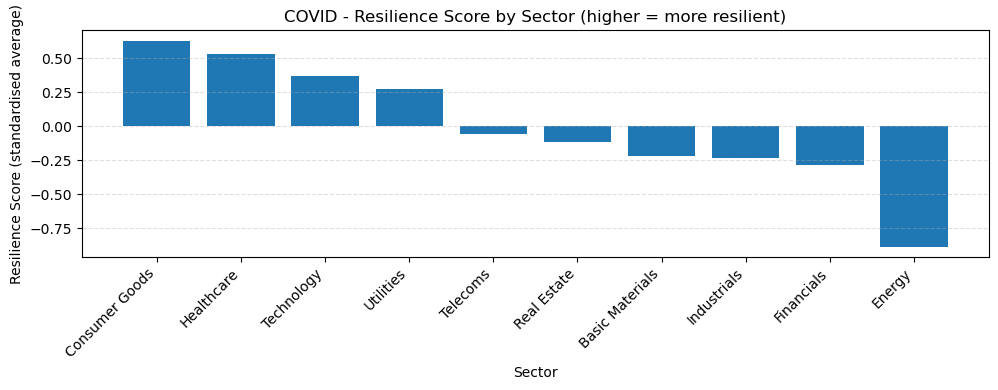

In [28]:
def resilience_ranking(features_df, title_prefix=""):
    cols = [
        "Impact (±60d, cum log)",
        "Volatility (±60d, std)",
        "Worst Day (±60d)",
        "Max Drawdown (±60d)",
    ]
    X = features_df[cols].copy()

    # Convert to "resilience direction":
    X_dir = pd.DataFrame(index=X.index)
    X_dir["Impact"] = X["Impact (±60d, cum log)"]
    X_dir["Volatility"] = -X["Volatility (±60d, std)"]
    X_dir["Worst Day"] = X["Worst Day (±60d)"]         
    X_dir["Max Drawdown"] = -X["Max Drawdown (±60d)"]   

    # Standardize each metric and take an equal-weight average
    Z = StandardScaler().fit_transform(X_dir.values)
    Z = pd.DataFrame(Z, index=X_dir.index, columns=X_dir.columns)

    # Equal-weight resilience score
    score = Z.mean(axis=1).rename("Resilience Score (z-avg)")
    ranking = pd.concat([score, X], axis=1).sort_values("Resilience Score (z-avg)", ascending=False)

    # Bar chart
    plt.figure(figsize=(10,4))
    plt.bar(ranking.index, ranking["Resilience Score (z-avg)"].values)
    plt.title(f"{title_prefix} - Resilience Score by Sector (higher = more resilient)")
    plt.xlabel("Sector")
    plt.ylabel("Resilience Score (standardised average)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    return ranking

ranking_brexit = resilience_ranking(features_brexit, "Brexit")
ranking_covid  = resilience_ranking(features_covid,  "COVID")

The resilience score summarizes multiple crisis-response metrics, including cumulative returns, volatility, worst-day losses, and maximum drawdown into a single standardized measure. Higher values indicate greater resilience, while negative values indicate higher vulnerability during the crisis period.

Comparing the two panels highlights a key finding of this study: sector resilience is highly crisis-dependent:
* Healthcare is consistently resilient across both crises, reinforcing its defensive characteristics.
* Consumer Goods and Technology perform better during COVID-19 than Brexit, reflecting the importance of essential consumption and digital services during lockdowns.
* Financials and Real Estate are particularly vulnerable during Brexit, while Energy becomes the most exposed sector during COVID-19.

The main similarity is that Healthcare  and Consumer Goods show up as the most robust across the two shocks, suggesting resilience is linked to stable demand/essential consumption rather than the specific crisis. The resilience rankings confirm that defensive sectors outperform during systemic crises Therefore, this shows us that it's often the same sectors that remain most resilient during crises. However, the identity of the most vulnerable sectors varies substantially with the type of shock and their underlying economic situations.

# Conclusion

This study examined how FTSE 100 sector resilience differed across the Brexit referendum and the COVID-19 market shock. The following findings synthesise the evidence across return dynamics, volatility patterns, and composite resilience measures.

**Finding 1: Crisis Type Drives Market Behaviour**

The analysis reveals that FTSE 100 sector resilience is not uniform across crises, but instead varies according to the nature of the shock. Brexit and COVID-19 represent fundamentally distinct events and therefore produced different market behaviours. Cumulative return time series show that only some sectors experienced modest declines around Brexit, whereas COVID-19 generated a sharp and near-simultaneous drop across almost all sectors, with Healthcare as a notable exception. This distinction allows us to characterize *COVID-19 as a systemic-sector shock and Brexit as an institutional-sector shock*. Sector responses to Brexit were closely tied to levels of domestic and regulatory exposure, while COVID-19 exerted broad downward pressure irrespective of sector classification. These patterns are consistently supported across multiple methods: cumulative return visualisations, PCA on resilience metrics, and the volatility heatmap, all of which indicate more modest and sometimes positive sector responses during Brexit, but widespread negative and high-volatility responses during COVID-19.

**Finding 2: Sector Resilience Is Crisis-Dependent**

*Sector resilience fluctuates based on the nature of the crisis* rather than being structurally fixed, meaning that the sectors most affected change according to the mechanism of the shock (for example, global macroeconomic, domestic policy, or public-health shocks). While the primary research question sought to identify which sectors appeared most resilient across both events, the results indicate that no single sector consistently occupies the most or least resilient position during crises. During Brexit, the weakest performance is concentrated in Financials and Real Estate, sectors with high exposure to domestic policy uncertainty, regulatory change, and investment confidence. In contrast, COVID-19 shifts vulnerability toward Energy and Industrials, sectors more directly tied to real-economy shutdowns, mobility restrictions, and global demand contraction. Event-window comparisons at both ±30 and ±60 trading days reinforce this distinction, showing deeper and more persistent losses in COVID-19 across companies within these sectors, while Brexit effects remain smaller and less synchronized. The composite resilience score and PCA further confirm that the identity of the least resilient sector is not stable across crises, but instead reflects the specific economic channel through which each shock moves.

**Finding 3: Partial Cross-Crisis Defensive Stability**

Despite the crisis-specific variation in vulnerability, a subset of sectors do demonstrate relatively stable defensive characteristics across both events. Healthcare and Consumer Goods consistently rank among the most resilient sectors, reflecting lower cyclicality and the persistence of essential demand even during periods of market stress. Technology also exhibits comparatively strong performance, particularly during COVID-19, where digital service demand partially offset broader economic contraction. Clustering results and resilience score rankings show these sectors grouping together across both crises, indicating a degree of cross-shock resilience that contrasts with the fluctuating vulnerability observed in Financials, Energy, and Industrials. This suggests that while crisis mechanisms alter which sectors suffer most, *certain sectors maintain comparatively defensive profiles* due to structural demand characteristics rather than short-term policy or macroeconomic fluctuations.

# References

Aroussi, Ran. “Yfinance.” *PyPI*, Python Software Foundation, 24 Jan. 2026, pypi.org/project/yfinance/.   

Bland, Greg. “Yfinance Library – A Complete Guide.” *AlgoTrading101*, AlgoTrading101 Blog, 3 Nov. 2020, algotrading101.com/learn/yfinance-guide/.   

Wikipedia contributors. “FTSE 100 Index.” *Wikipedia*,  Wikimedia Foundation, Inc., 20 Jan. 2026, en.wikipedia.org/wiki/FTSE_100_Index.   

Greater London Authority. “EU Referendum Results.” *London Datastore*,  Greater London Authority, 2016, data.london.gov.uk/dataset/eu-referendum-results-2y548/.   

UKHSA. “COVID-19.” *Gov.UK*,  UK Government, 2016, ukhsa-dashboard.data.gov.uk/respiratory-viruses/covid-19.   

Morris, Christopher. “FTSE 100 Sector Breakdown: Which Industries Dominate?” *ftse100index*,  ftse100index.com, 3 May. 2025, ftse100index.com/ftse-100-sector-breakdown/   
